数据形状: (1510, 8)

数据前5行:
   id  Depth  Temperature  Salinity  Oxygen      pH  DO_mgL  QualityLevel
0   1   0.00      23.8058   34.6166   212.9  7.9316  6.8128             3
1   2  11.62      23.8044   34.6166   212.3  8.0877  6.7936             3
2   3  22.05      23.8117   34.6166   212.5  8.0876  6.8000             3
3   4  31.59      23.8034   34.6166   212.2  8.0890  6.7904             3
4   5  50.06      23.4602   34.6166   211.0  8.0798  6.7520             3

数据基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1510 non-null   int64  
 1   Depth         1510 non-null   float64
 2   Temperature   1510 non-null   float64
 3   Salinity      1510 non-null   float64
 4   Oxygen        1510 non-null   float64
 5   pH            1510 non-null   float64
 6   DO_mgL        1510 non-null   float64
 7   QualityLevel  1510 non-nu

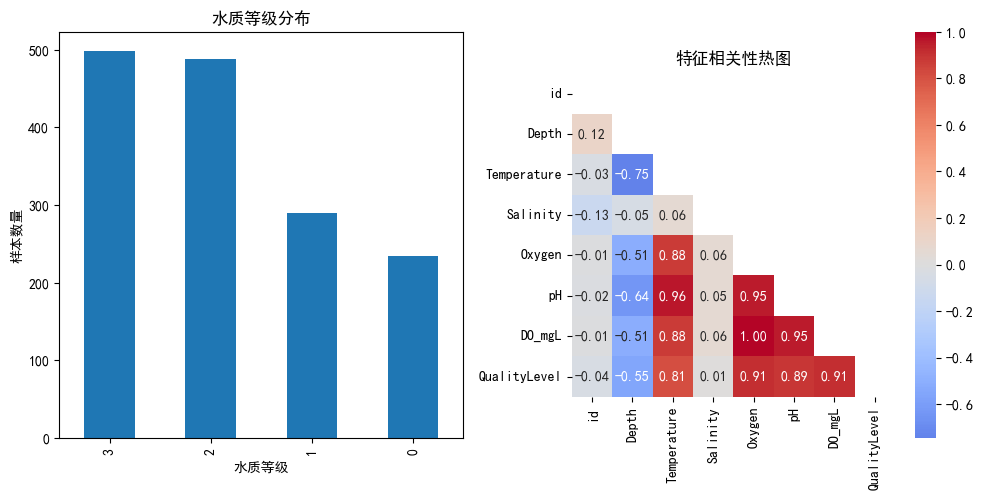


训练集大小: (1208, 6)
测试集大小: (302, 6)
训练集类别分布: [187 232 390 399]
测试集类别分布: [47 58 98 99]


(        Depth  Temperature  Salinity  Oxygen      pH   DO_mgL
 501    150.17      19.9786   34.7899  213.85  8.0236  6.84320
 538    149.68      19.4532   34.7982  206.60  7.9986  6.61120
 1009   603.89       9.3382   34.3498  126.50  7.6414  4.04800
 1407   150.46      20.6115   34.8477  196.58  7.9896  6.29056
 515   1799.60       2.1605   34.5833  100.96  7.4927  3.23072
 ...       ...          ...       ...     ...     ...      ...
 338     51.26      23.9286   34.6166  215.50  8.0563  6.89600
 1175   900.22       6.1013   34.3344   91.40  7.5083  2.92480
 865    499.96      10.7225   34.2875  159.30  7.7205  5.09760
 402   1800.79       2.0988   34.5971  108.30  7.4979  3.46560
 1428   570.57       9.0857   34.1971  141.38  7.6362  4.52416
 
 [1208 rows x 6 columns],
          Depth  Temperature  Salinity  Oxygen      pH   DO_mgL
 1352   800.272       5.4440   34.6166   77.09  7.4456  2.46688
 339     76.390      20.5407   34.6166  218.80  8.0207  7.00160
 687   1202.020       3.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 加载数据
def load_water_quality_data(filename):
    """
    加载水质数据
    列：Depth, Temperature, Salinity, Oxygen, pH, DO_mgL, QualityLevel
    """
    df = pd.read_csv('waterdata_ready_for_ml_weighted_no_unit.csv')
    print("数据形状:", df.shape)
    print("\n数据前5行:")
    print(df.head())
    print("\n数据基本信息:")
    print(df.info())
    print("\n数据描述统计:")
    print(df.describe())
    
    return df

# 2. 数据探索和预处理
def explore_and_preprocess(df):
    """
    数据探索和预处理
    """
    
    # 检查水质等级的分布
    print("\n水质等级分布:")
    print(df['QualityLevel'].value_counts())
    
    # 可视化水质等级分布
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    df['QualityLevel'].value_counts().plot(kind='bar')
    plt.title('水质等级分布')
    plt.xlabel('水质等级')
    plt.ylabel('样本数量')
    
    # 特征之间的相关性分析
    plt.subplot(1, 2, 2)
    # 如果QualityLevel是字符串，需要先编码
    if df['QualityLevel'].dtype == 'object':
        le = LabelEncoder()
        df['QualityLevel_encoded'] = le.fit_transform(df['QualityLevel'])
        corr_df = df.drop('QualityLevel', axis=1)
    else:
        corr_df = df.copy()
    
    correlation = corr_df.corr()
    mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
    sns.heatmap(correlation, mask=mask, annot=True, cmap='coolwarm', center=0,fmt='.2f',square=True)
    plt.title('特征相关性热图')
    plt.tight_layout()
    plt.show()
    
    return df

# 3. 准备训练数据
def prepare_data(df):
    """
    准备训练和测试数据
    """
    # 分离特征和目标变量
    features = ['Depth', 'Temperature', 'Salinity', 'Oxygen', 'pH', 'DO_mgL']
    X = df[features]
    
    # 处理标签
    if df['QualityLevel'].dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(df['QualityLevel'])
        # 保存标签映射关系
        label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
        print(f"标签映射关系: {label_mapping}")
    else:
        y = df['QualityLevel']
    
    # 分割数据集
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\n训练集大小: {X_train.shape}")
    print(f"测试集大小: {X_test.shape}")
    print(f"训练集类别分布: {np.bincount(y_train)}")
    print(f"测试集类别分布: {np.bincount(y_test)}")
    
    return X_train, X_test, y_train, y_test, features

df = load_water_quality_data('waterdata_ready_for_ml_weighted_no_unit.csv')
explore_and_preprocess(df)
prepare_data(df)

In [9]:
# 4. 训练基础决策树模型
X_train, X_test, y_train, y_test, features=prepare_data(df)
def train_baseline_decision_tree(X_train, X_test, y_train, y_test, features):
    """
    训练和评估基础决策树模型
    """
    print("\n" + "="*50)
    print("1. 基础决策树模型")
    print("="*50)
    
    # 使用基尼系数作为分裂标准
    dt_gini = DecisionTreeClassifier(
        criterion='gini',
        random_state=42
    )
    
    # 使用信息增益作为分裂标准
    dt_entropy = DecisionTreeClassifier(
        criterion='entropy',
        random_state=42
    )
    
    # 训练模型
    dt_gini.fit(X_train, y_train)
    dt_entropy.fit(X_train, y_train)
    
    # 预测
    y_pred_gini = dt_gini.predict(X_test)
    y_pred_entropy = dt_entropy.predict(X_test)
    
    # 评估
    print("\n基尼系数模型:")
    print(f"训练集准确率: {dt_gini.score(X_train, y_train):.4f}")
    print(f"测试集准确率: {accuracy_score(y_test, y_pred_gini):.4f}")
    
    print("\n信息增益模型:")
    print(f"训练集准确率: {dt_entropy.score(X_train, y_train):.4f}")
    print(f"测试集准确率: {accuracy_score(y_test, y_pred_entropy):.4f}")
    
    # 特征重要性
    print("\n特征重要性 (基尼系数模型):")
    for feature, importance in zip(features, dt_gini.feature_importances_):
        print(f"  {feature}: {importance:.4f}")
    
    return dt_gini, dt_entropy, y_pred_gini, y_pred_entropy

dt_gini, dt_entropy, y_pred_gini, y_pred_entropy=train_baseline_decision_tree(X_train, X_test, y_train, y_test, features)


训练集大小: (1208, 6)
测试集大小: (302, 6)
训练集类别分布: [187 232 390 399]
测试集类别分布: [47 58 98 99]

1. 基础决策树模型

基尼系数模型:
训练集准确率: 1.0000
测试集准确率: 0.9901

信息增益模型:
训练集准确率: 1.0000
测试集准确率: 0.9934

特征重要性 (基尼系数模型):
  Depth: 0.0000
  Temperature: 0.4371
  Salinity: 0.0160
  Oxygen: 0.2352
  pH: 0.3080
  DO_mgL: 0.0038



2. 决策树剪枝策略


<Figure size 1500x1000 with 0 Axes>

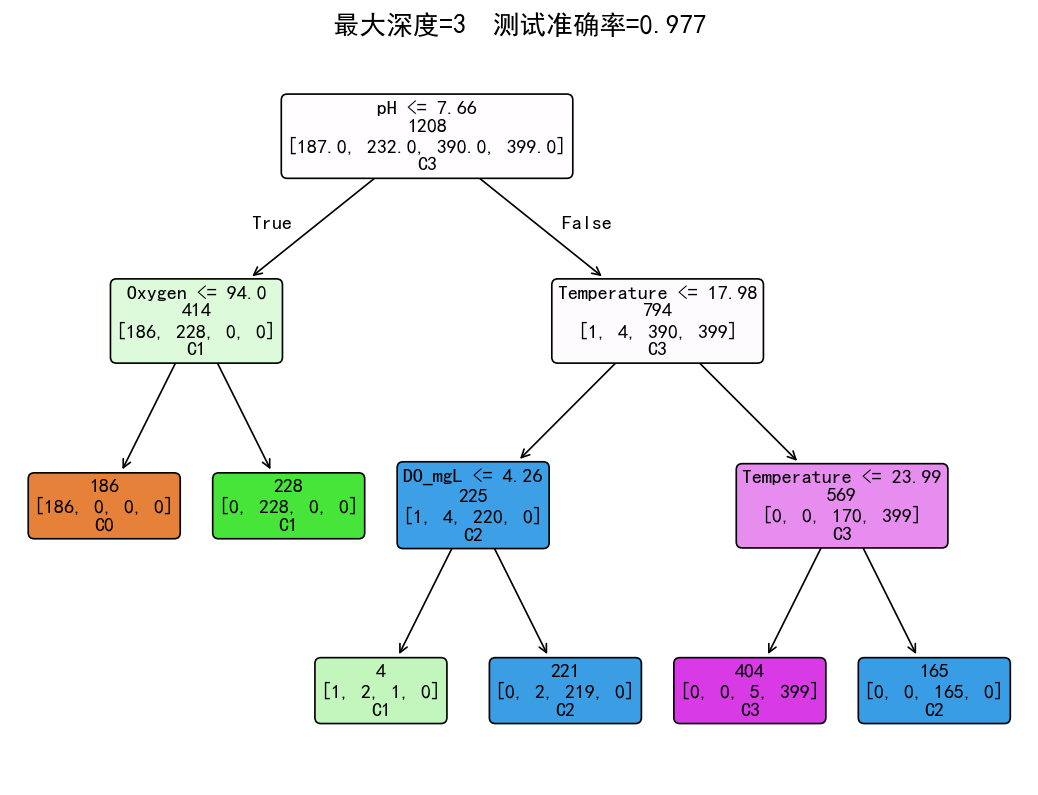

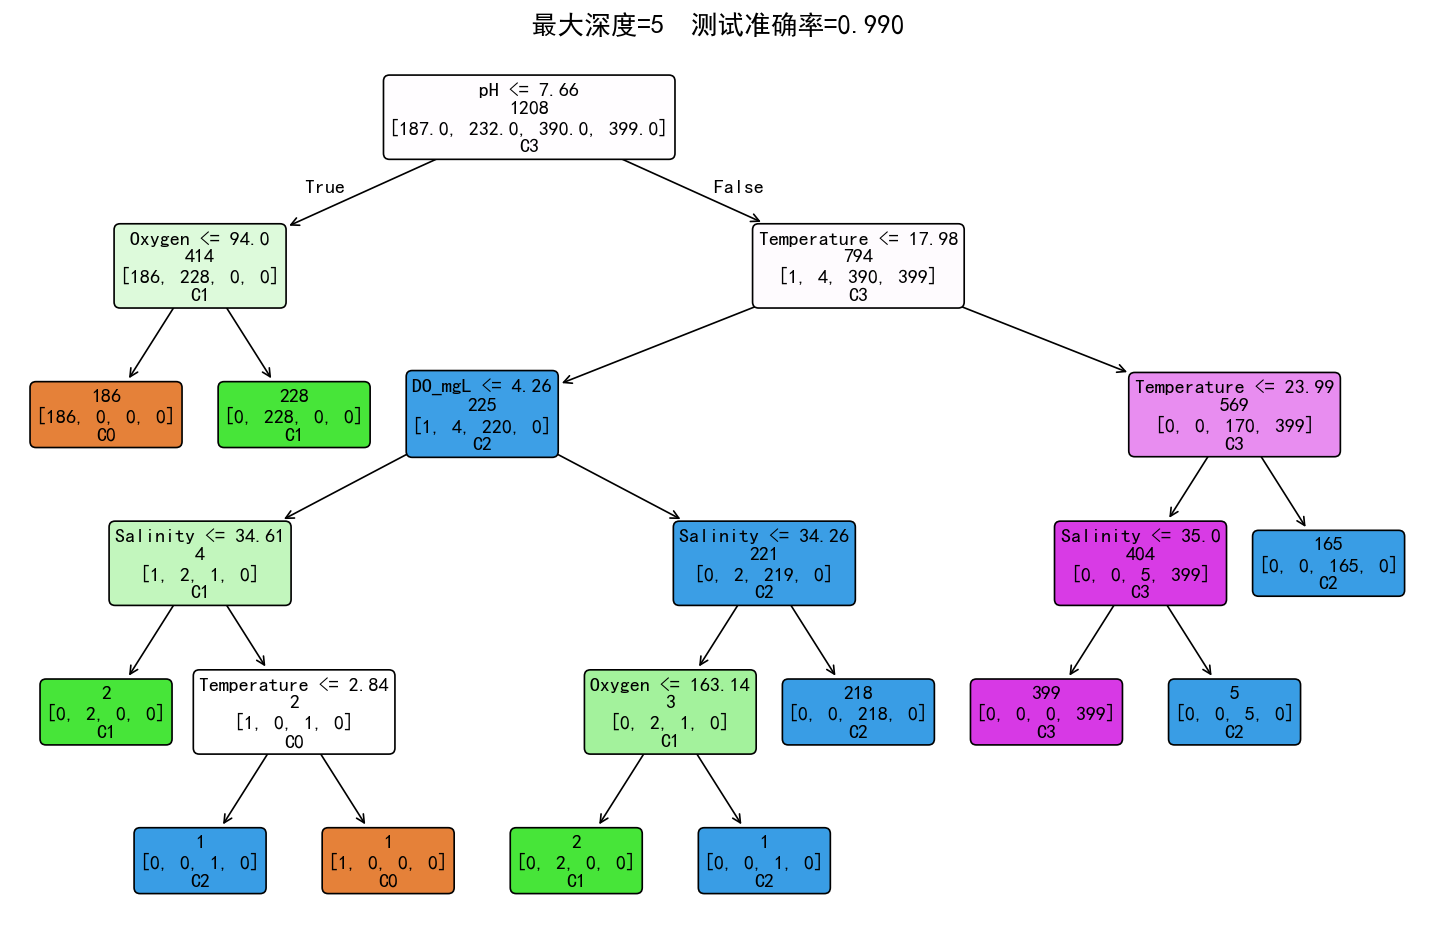


不同最大深度的表现:
 max_depth  train_score  test_score  n_nodes  n_leaves
       3.0      0.99255    0.976821       11         6
       5.0      1.00000    0.990066       21        11
       7.0      1.00000    0.990066       21        11
      10.0      1.00000    0.990066       21        11
      15.0      1.00000    0.990066       21        11
      20.0      1.00000    0.990066       21        11
       NaN      1.00000    0.990066       21        11


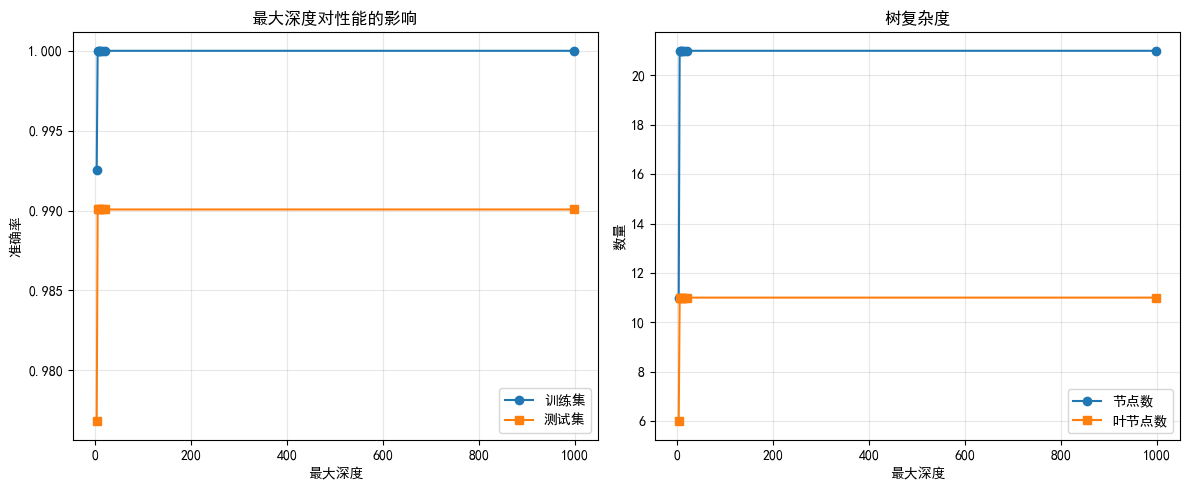

,max_depth,train_score,test_score,n_nodes,n_leaves
0,3.0,0.99255,0.976821,11,6
1,5.0,1.00000,0.990066,21,11
2,7.0,1.00000,0.990066,21,11
3,10.0,1.00000,0.990066,21,11
4,15.0,1.00000,0.990066,21,11
5,20.0,1.00000,0.990066,21,11
6,NaN,1.00000,0.990066,21,11


In [10]:
# 5. 决策树剪枝策略
def train_pruned_decision_trees(X_train, X_test, y_train, y_test, features):
    """
    使用不同剪枝策略训练决策树
    """
    print("\n" + "="*50)
    print("2. 决策树剪枝策略")
    print("="*50)
    
    # 尝试不同最大深度
    max_depths = [3, 5, 7, 10, 15, 20, None]
    results = []
    
    plt.figure(figsize=(15, 10))
    for i, max_depth in enumerate(max_depths):
        dt = DecisionTreeClassifier(
            max_depth=max_depth,
            criterion='gini',
            random_state=42
        )
        dt.fit(X_train, y_train)
        
        train_score = dt.score(X_train, y_train)
        test_score = dt.score(X_test, y_test)
        
        results.append({
            'max_depth': max_depth,
            'train_score': train_score,
            'test_score': test_score,
            'n_nodes': dt.tree_.node_count,
            'n_leaves': dt.get_n_leaves()
        })
        
        # 可视化深度为3和5的树
        if max_depth in [3, 5]:
            plt.figure(figsize=(24, 8))          # 一张大图，1 行 2 列
            pos = 1 if max_depth == 3 else 2
            plt.subplot(1, 2, pos)

            # 用更大的画布单独画树
            plt.gcf().set_dpi(120)               # 再提高 dpi
            plot_tree(
                dt,
                feature_names=features,
                class_names=[f'C{i}' for i in np.unique(y_train)],
                filled=True,
                rounded=True,
                fontsize=12,                     # 字号继续放大
                proportion=False,                 # 只显示比例
                impurity=False,                  # 不印基尼值
                label='none',                    # 不印样本数
                precision=2                      # 小数保留 2 位
            )
            plt.title(f'最大深度={max_depth}  测试准确率={test_score:.3f}',
                    fontsize=16)
            plt.axis('off')                      # 去掉坐标轴边框
    
    plt.tight_layout()
    plt.show()
    
    # 创建结果DataFrame
    results_df = pd.DataFrame(results)
    print("\n不同最大深度的表现:")
    print(results_df.to_string(index=False))
    
    # 绘制学习曲线
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(results_df['max_depth'].fillna('999'), results_df['train_score'], 'o-', label='训练集')
    plt.plot(results_df['max_depth'].fillna('999'), results_df['test_score'], 's-', label='测试集')
    plt.xlabel('最大深度')
    plt.ylabel('准确率')
    plt.title('最大深度对性能的影响')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(results_df['max_depth'].fillna('999'), results_df['n_nodes'], 'o-', label='节点数')
    plt.plot(results_df['max_depth'].fillna('999'), results_df['n_leaves'], 's-', label='叶节点数')
    plt.xlabel('最大深度')
    plt.ylabel('数量')
    plt.title('树复杂度')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results_df

train_pruned_decision_trees(X_train, X_test, y_train, y_test, features)


3. 网格搜索优化
开始网格搜索...
Fitting 3 folds for each of 576 candidates, totalling 1728 fits

最佳参数: {'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
最佳交叉验证分数: 0.9959
测试集准确率: 0.9901

最佳模型特征重要性:
  Depth: 0.0000
  Temperature: 0.4371
  Salinity: 0.0160
  Oxygen: 0.2352
  pH: 0.3080
  DO_mgL: 0.0038


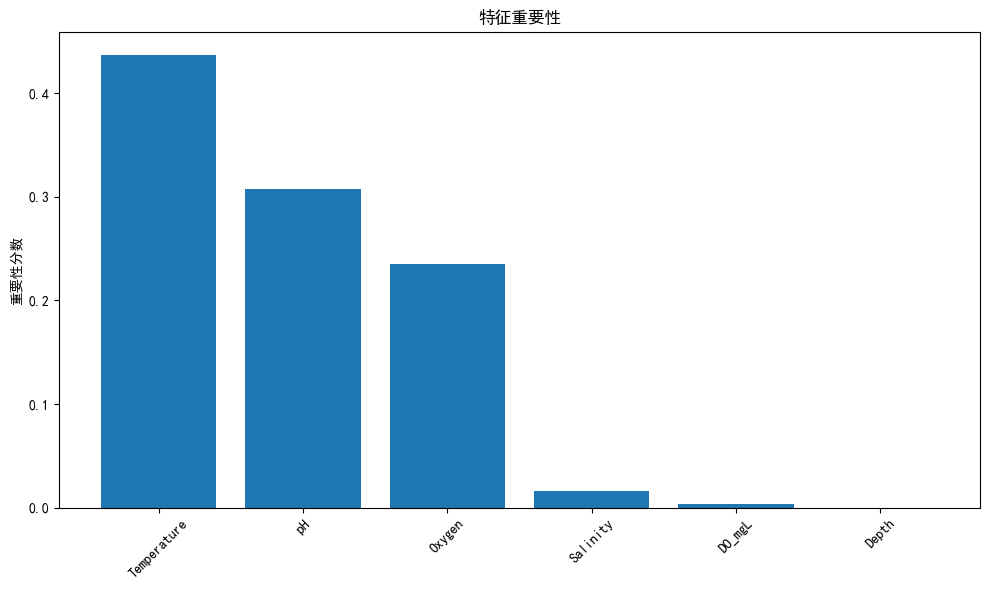

In [11]:
# 6. 网格搜索寻找最优参数
def grid_search_optimization(X_train, X_test, y_train, y_test, features):
    """
    使用网格搜索优化决策树超参数
    """
    print("\n" + "="*50)
    print("3. 网格搜索优化")
    print("="*50)
    
    # 定义参数网格
    param_grid = {
        'criterion': ['gini', 'entropy'],
        'max_depth': [3, 5, 7, 10, 15, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 5, 10],
        'max_features': ['sqrt', 'log2', None]
    }
    
    # 创建基础模型
    dt = DecisionTreeClassifier(random_state=42)
    
    # 网格搜索（为了节省时间，可以使用较小的网格或随机搜索）
    # 这里我们使用3折交叉验证
    grid_search = GridSearchCV(
        dt,
        param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    print("开始网格搜索...")
    grid_search.fit(X_train, y_train)
    
    print(f"\n最佳参数: {grid_search.best_params_}")
    print(f"最佳交叉验证分数: {grid_search.best_score_:.4f}")
    
    # 使用最佳模型进行预测
    best_dt = grid_search.best_estimator_
    y_pred = best_dt.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)
    print(f"测试集准确率: {test_accuracy:.4f}")
    
    # 特征重要性
    print("\n最佳模型特征重要性:")
    for feature, importance in zip(features, best_dt.feature_importances_):
        print(f"  {feature}: {importance:.4f}")
    
    # 可视化特征重要性
    plt.figure(figsize=(10, 6))
    importances = best_dt.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.title('特征重要性')
    plt.bar(range(len(features)), importances[indices])
    plt.xticks(range(len(features)), [features[i] for i in indices], rotation=45)
    plt.ylabel('重要性分数')
    plt.tight_layout()
    plt.show()
    
    return best_dt, y_pred

best_dt, y_pred=grid_search_optimization(X_train, X_test, y_train, y_test, features)


4. 决策树模型评估
准确率: 0.990066

分类报告:
              precision    recall  f1-score   support

       水质等级0       0.98      0.98      0.98        47
       水质等级1       0.97      0.98      0.97        58
       水质等级2       1.00      0.99      0.99        98
       水质等级3       1.00      1.00      1.00        99

    accuracy                           0.99       302
   macro avg       0.99      0.99      0.99       302
weighted avg       0.99      0.99      0.99       302



<Figure size 1000x800 with 0 Axes>

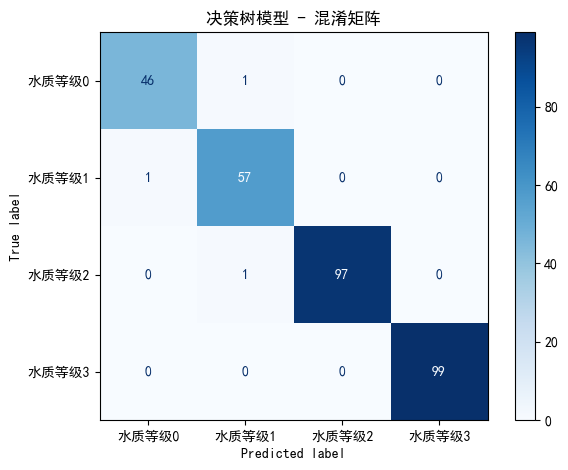

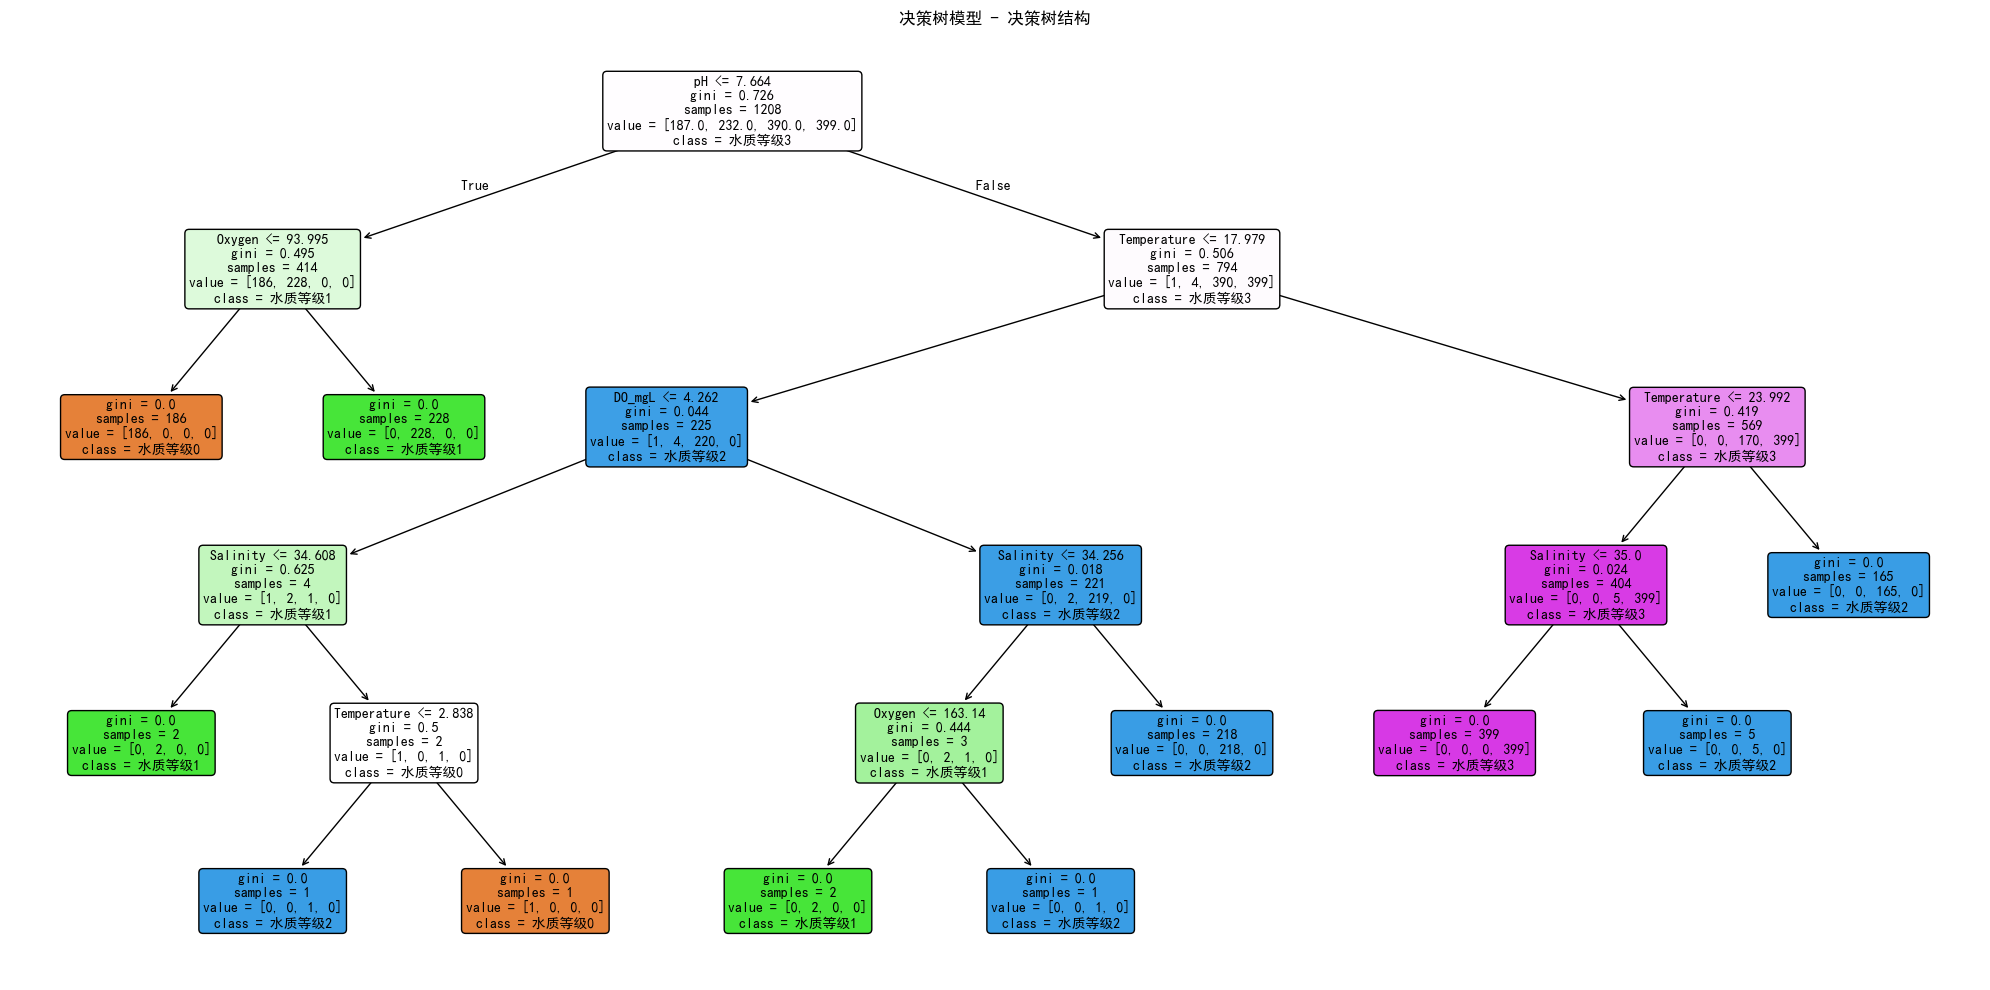

0.9900662251655629

In [12]:
# 7. 模型评估和可视化
def evaluate_model(model, X_test, y_test, y_pred, features, model_name="决策树模型"):
    """
    全面评估模型性能
    """
    print("\n" + "="*50)
    print(f"4. {model_name}评估")
    print("="*50)
    
    # 准确率
    accuracy = accuracy_score(y_test, y_pred)
    print(f"准确率: {accuracy:.6f}")
    
    # 分类报告
    print("\n分类报告:")
    print(classification_report(y_test, y_pred, 
                               target_names=[f'水质等级{i}' for i in np.unique(y_test)]))
    
    # 混淆矩阵
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=[f'水质等级{i}' for i in np.unique(y_test)])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'{model_name} - 混淆矩阵')
    plt.tight_layout()
    plt.show()
    
    # 可视化决策树（如果树不太大）
    if hasattr(model, 'tree_') and model.tree_.node_count < 50:
        plt.figure(figsize=(20, 10))
        plot_tree(model, 
                 feature_names=features,
                 class_names=[f'水质等级{i}' for i in np.unique(y_test)],
                 filled=True,
                 rounded=True,
                 fontsize=10)
        plt.title(f'{model_name} - 决策树结构')
        plt.tight_layout()
        plt.show()
    
    return accuracy

evaluate_model(best_dt, X_test, y_test, y_pred, features, model_name="决策树模型")


5折分层交叉验证对比
          模型    准确率均值   准确率标准差   加权F1均值  加权F1标准差
决策树-网格搜索最优参数 0.997351 0.002478 0.997350 0.002478
    决策树-默认参数 0.997351 0.002478 0.997350 0.002478
   逻辑回归-原始特征 0.829139 0.021723 0.828762 0.021545
  逻辑回归-分组PCA 0.806623 0.025008 0.806200 0.025117

各折准确率明细:
决策树-网格搜索最优参数: [0.9934, 1.0, 1.0, 0.9967, 0.9967]
决策树-默认参数: [0.9934, 1.0, 1.0, 0.9967, 0.9967]
逻辑回归-原始特征: [0.798, 0.8444, 0.8113, 0.8344, 0.8576]
逻辑回归-分组PCA: [0.7715, 0.8278, 0.7815, 0.8311, 0.8212]


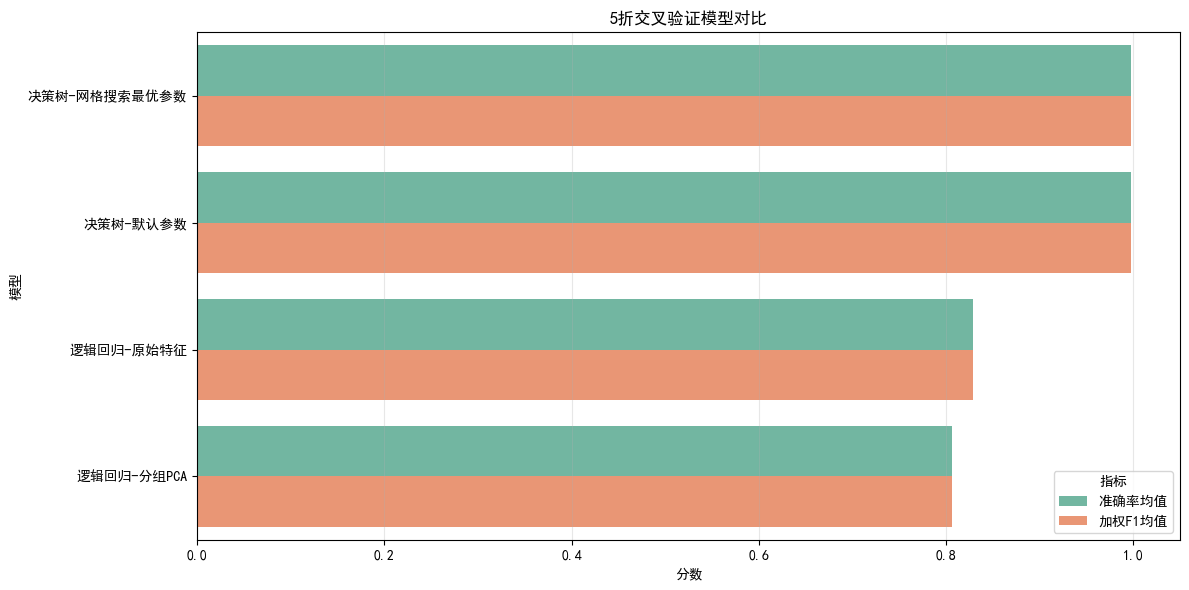


结论提示:
交叉验证下表现最好的模型是: 决策树-网格搜索最优参数
平均准确率: 0.9974 +/- 0.0025
如果标准差很小，说明模型在不同数据切分下更稳定；如果标准差明显偏大，则单次测试集高分可能不稳。


In [13]:
# 8. 交叉验证对比（同一数据、同一折法）
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, f1_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


class GroupedPCATransformer(BaseEstimator, TransformerMixin):
    def __init__(self, group1, group2, independent_features):
        self.group1 = group1
        self.group2 = group2
        self.independent_features = independent_features

    def fit(self, X, y=None):
        self.scaler_group1_ = StandardScaler()
        self.scaler_group2_ = StandardScaler()
        self.pca_group1_ = PCA(n_components=1)
        self.pca_group2_ = PCA(n_components=1)

        group1_scaled = self.scaler_group1_.fit_transform(X[self.group1])
        group2_scaled = self.scaler_group2_.fit_transform(X[self.group2])

        self.pca_group1_.fit(group1_scaled)
        self.pca_group2_.fit(group2_scaled)
        return self

    def transform(self, X):
        group1_scaled = self.scaler_group1_.transform(X[self.group1])
        group2_scaled = self.scaler_group2_.transform(X[self.group2])

        transformed = pd.DataFrame(index=X.index)
        transformed['PC1_oxygen'] = self.pca_group1_.transform(group1_scaled).ravel()
        transformed['PC1_temp_pH'] = self.pca_group2_.transform(group2_scaled).ravel()

        for feature in self.independent_features:
            transformed[feature] = X[feature].values

        return transformed


X_full = df[features].copy()
if df['QualityLevel'].dtype == 'object':
    label_encoder_cv = LabelEncoder()
    y_full = label_encoder_cv.fit_transform(df['QualityLevel'])
else:
    y_full = df['QualityLevel'].to_numpy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'f1_weighted': make_scorer(f1_score, average='weighted')
}

log_reg_raw = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=2000,
        random_state=42
    ))
])

log_reg_grouped_pca = Pipeline([
    ('grouped_pca', GroupedPCATransformer(
        group1=['Oxygen', 'DO_mgL'],
        group2=['Temperature', 'pH'],
        independent_features=['Depth', 'Salinity']
    )),
    ('model', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=2000,
        random_state=42
    ))
])

model_candidates = {
    '逻辑回归-原始特征': log_reg_raw,
    '逻辑回归-分组PCA': log_reg_grouped_pca,
    '决策树-默认参数': DecisionTreeClassifier(random_state=42),
    '决策树-网格搜索最优参数': best_dt
}

cv_rows = []
print('\n' + '=' * 70)
print('5折分层交叉验证对比')
print('=' * 70)
for model_name, estimator in model_candidates.items():
    scores = cross_validate(estimator, X_full, y_full, cv=cv, scoring=scoring, n_jobs=-1)
    acc_scores = scores['test_accuracy']
    f1_scores = scores['test_f1_weighted']

    cv_rows.append({
        '模型': model_name,
        '准确率均值': acc_scores.mean(),
        '准确率标准差': acc_scores.std(),
        '加权F1均值': f1_scores.mean(),
        '加权F1标准差': f1_scores.std(),
        '各折准确率': np.round(acc_scores, 4).tolist()
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values('准确率均值', ascending=False)
print(cv_results_df[['模型', '准确率均值', '准确率标准差', '加权F1均值', '加权F1标准差']].to_string(index=False))

print('\n各折准确率明细:')
for _, row in cv_results_df.iterrows():
    print(f"{row['模型']}: {row['各折准确率']}")

plt.figure(figsize=(12, 6))
plot_df = cv_results_df.melt(
    id_vars='模型',
    value_vars=['准确率均值', '加权F1均值'],
    var_name='指标',
    value_name='分数'
)
sns.barplot(data=plot_df, x='分数', y='模型', hue='指标', palette='Set2')
plt.xlim(0, 1.05)
plt.title('5折交叉验证模型对比')
plt.xlabel('分数')
plt.ylabel('模型')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

best_row = cv_results_df.iloc[0]
print('\n结论提示:')
print(f"交叉验证下表现最好的模型是: {best_row['模型']}")
print(f"平均准确率: {best_row['准确率均值']:.4f} +/- {best_row['准确率标准差']:.4f}")
print('如果标准差很小，说明模型在不同数据切分下更稳定；如果标准差明显偏大，则单次测试集高分可能不稳。')


5折分层交叉验证扩展对比：逻辑回归、决策树、随机森林、XGBoost
          模型    准确率均值   准确率标准差   加权F1均值  加权F1标准差
    决策树-默认参数 0.997351 0.002478 0.997350 0.002478
  随机森林-300棵树 0.995364 0.002649 0.995368 0.002646
XGBoost-基准参数 0.992053 0.002649 0.992062 0.002641
   逻辑回归-原始特征 0.829139 0.021723 0.828762 0.021545
  逻辑回归-分组PCA 0.806623 0.025008 0.806200 0.025117

各折准确率明细:
决策树-默认参数: [0.9934, 1.0, 1.0, 0.9967, 0.9967]
随机森林-300棵树: [0.9934, 0.9967, 1.0, 0.9934, 0.9934]
XGBoost-基准参数: [0.9934, 0.9934, 0.9868, 0.9934, 0.9934]
逻辑回归-原始特征: [0.798, 0.8444, 0.8113, 0.8344, 0.8576]
逻辑回归-分组PCA: [0.7715, 0.8278, 0.7815, 0.8311, 0.8212]


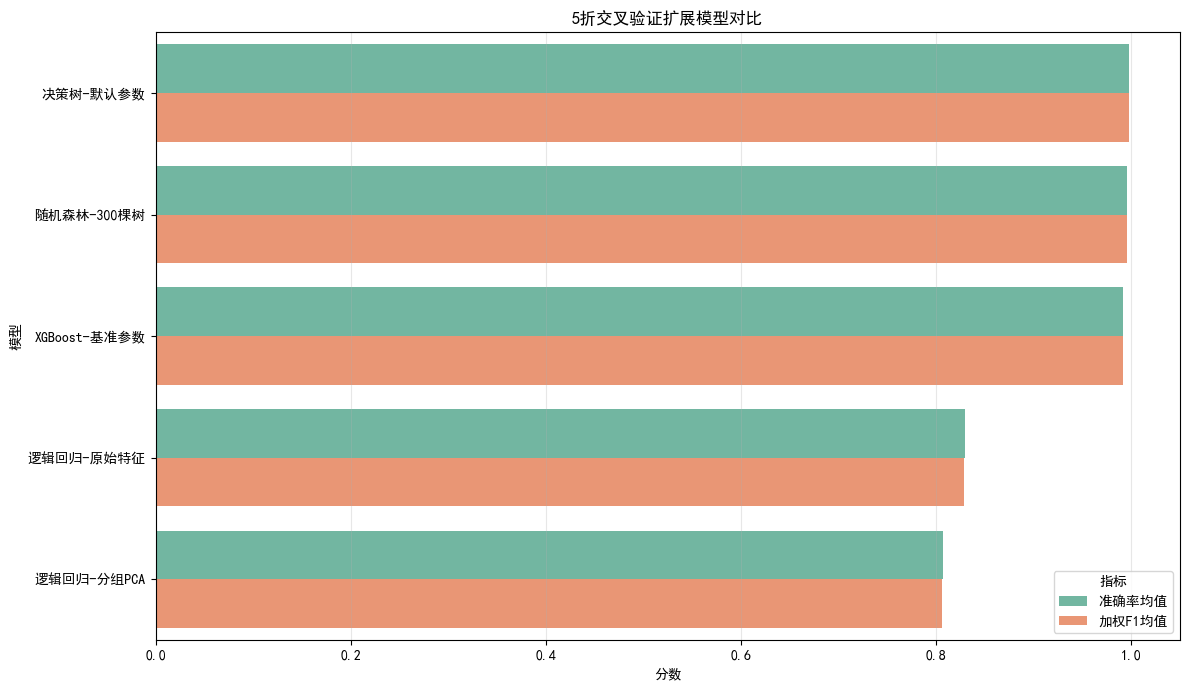


结论提示:
当前扩展对比中表现最好的模型: 决策树-默认参数
平均准确率: 0.9974 +/- 0.0025
如果随机森林和 XGBoost 没有明显超过单棵决策树，说明这份数据上的规则边界已经非常容易被树模型学习到。


In [14]:
# 9. 扩展基准对照：加入随机森林和 XGBoost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


class GroupedPCATransformer(BaseEstimator, TransformerMixin):
    def __init__(self, group1, group2, independent_features):
        self.group1 = group1
        self.group2 = group2
        self.independent_features = independent_features

    def fit(self, X, y=None):
        self.scaler_group1_ = StandardScaler()
        self.scaler_group2_ = StandardScaler()
        self.pca_group1_ = PCA(n_components=1)
        self.pca_group2_ = PCA(n_components=1)

        self.pca_group1_.fit(self.scaler_group1_.fit_transform(X[self.group1]))
        self.pca_group2_.fit(self.scaler_group2_.fit_transform(X[self.group2]))
        return self

    def transform(self, X):
        transformed = pd.DataFrame(index=X.index)
        transformed['PC1_oxygen'] = self.pca_group1_.transform(
            self.scaler_group1_.transform(X[self.group1])
        ).ravel()
        transformed['PC1_temp_pH'] = self.pca_group2_.transform(
            self.scaler_group2_.transform(X[self.group2])
        ).ravel()

        for feature in self.independent_features:
            transformed[feature] = X[feature].values
        return transformed


df_cv = pd.read_csv('waterdata_ready_for_ml_weighted_no_unit.csv')
feature_columns = ['Depth', 'Temperature', 'Salinity', 'Oxygen', 'pH', 'DO_mgL']
X_cv = df_cv[feature_columns].copy()

if df_cv['QualityLevel'].dtype == 'object':
    label_encoder_cv = LabelEncoder()
    y_cv = label_encoder_cv.fit_transform(df_cv['QualityLevel'])
else:
    y_cv = df_cv['QualityLevel'].to_numpy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'f1_weighted': make_scorer(f1_score, average='weighted')
}

log_reg_raw = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=2000,
        random_state=42
    ))
])

log_reg_grouped_pca = Pipeline([
    ('grouped_pca', GroupedPCATransformer(
        group1=['Oxygen', 'DO_mgL'],
        group2=['Temperature', 'pH'],
        independent_features=['Depth', 'Salinity']
    )),
    ('model', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=2000,
        random_state=42
    ))
])

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y_cv)),
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    tree_method='hist',
    eval_metric='mlogloss'
)

model_candidates_extended = {
    '逻辑回归-原始特征': log_reg_raw,
    '逻辑回归-分组PCA': log_reg_grouped_pca,
    '决策树-默认参数': DecisionTreeClassifier(random_state=42),
    '随机森林-300棵树': rf_model,
    'XGBoost-基准参数': xgb_model
}

extended_rows = []
print('\n' + '=' * 72)
print('5折分层交叉验证扩展对比：逻辑回归、决策树、随机森林、XGBoost')
print('=' * 72)
for model_name, estimator in model_candidates_extended.items():
    scores = cross_validate(estimator, X_cv, y_cv, cv=cv, scoring=scoring, n_jobs=-1)
    acc_scores = scores['test_accuracy']
    f1_scores = scores['test_f1_weighted']
    extended_rows.append({
        '模型': model_name,
        '准确率均值': acc_scores.mean(),
        '准确率标准差': acc_scores.std(),
        '加权F1均值': f1_scores.mean(),
        '加权F1标准差': f1_scores.std(),
        '各折准确率': np.round(acc_scores, 4).tolist()
    })

extended_cv_results_df = pd.DataFrame(extended_rows).sort_values('准确率均值', ascending=False)
print(extended_cv_results_df[['模型', '准确率均值', '准确率标准差', '加权F1均值', '加权F1标准差']].to_string(index=False))

print('\n各折准确率明细:')
for _, row in extended_cv_results_df.iterrows():
    print(f"{row['模型']}: {row['各折准确率']}")

plt.figure(figsize=(12, 7))
plot_df = extended_cv_results_df.melt(
    id_vars='模型',
    value_vars=['准确率均值', '加权F1均值'],
    var_name='指标',
    value_name='分数'
)
sns.barplot(data=plot_df, x='分数', y='模型', hue='指标', palette='Set2')
plt.xlim(0, 1.05)
plt.title('5折交叉验证扩展模型对比')
plt.xlabel('分数')
plt.ylabel('模型')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

best_extended = extended_cv_results_df.iloc[0]
print('\n结论提示:')
print(f"当前扩展对比中表现最好的模型: {best_extended['模型']}")
print(f"平均准确率: {best_extended['准确率均值']:.4f} +/- {best_extended['准确率标准差']:.4f}")
print('如果随机森林和 XGBoost 没有明显超过单棵决策树，说明这份数据上的规则边界已经非常容易被树模型学习到。')

In [15]:
# 10. 提取决策树规则，并与 level.py 的 QualityLevel 生成逻辑对比
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

df_rules = pd.read_csv('waterdata_ready_for_ml_weighted_no_unit.csv')
rule_features = ['Depth', 'Temperature', 'Salinity', 'Oxygen', 'pH', 'DO_mgL']
X_rules = df_rules[rule_features].copy()

if df_rules['QualityLevel'].dtype == 'object':
    label_encoder_rules = LabelEncoder()
    y_rules = label_encoder_rules.fit_transform(df_rules['QualityLevel'])
else:
    y_rules = df_rules['QualityLevel'].to_numpy()

rule_tree = DecisionTreeClassifier(random_state=42)
rule_tree.fit(X_rules, y_rules)

print('\n' + '=' * 72)
print('基于全量数据拟合的决策树规则')
print('=' * 72)
print(f'训练集准确率: {rule_tree.score(X_rules, y_rules):.4f}')

feature_importance_df = pd.DataFrame({
    '特征': rule_features,
    '重要性': rule_tree.feature_importances_
}).sort_values('重要性', ascending=False)
print('\n特征重要性:')
print(feature_importance_df.to_string(index=False))

tree_rules_text = export_text(rule_tree, feature_names=rule_features, decimals=3)
print('\n决策树文本规则:')
print(tree_rules_text)

used_feature_indices = rule_tree.tree_.feature
used_thresholds = rule_tree.tree_.threshold
feature_thresholds = {}
for feature_index, threshold in zip(used_feature_indices, used_thresholds):
    if feature_index >= 0:
        feature_name = rule_features[feature_index]
        feature_thresholds.setdefault(feature_name, []).append(float(threshold))

for feature_name in feature_thresholds:
    unique_values = sorted(set(round(value, 3) for value in feature_thresholds[feature_name]))
    feature_thresholds[feature_name] = unique_values

expected_thresholds = {
    'DO_mgL': [3.0, 4.0, 5.0],
    'pH': [6.0, 7.0, 7.8, 8.5, 9.0],
    'Temperature': [10.0, 15.0, 18.0, 24.0, 28.0, 30.0],
    'Salinity': [15.0, 20.0, 24.0, 32.0, 35.0, 38.0]
}

print('\n树中实际使用过的阈值:')
for feature_name, thresholds in feature_thresholds.items():
    print(f'{feature_name}: {thresholds}')

comparison_rows = []
for feature_name, expected_list in expected_thresholds.items():
    actual_list = feature_thresholds.get(feature_name, [])
    if actual_list:
        matched_pairs = []
        for expected in expected_list:
            nearest = min(actual_list, key=lambda actual: abs(actual - expected))
            matched_pairs.append(f'{expected} -> {nearest}')
        matched_text = '; '.join(matched_pairs)
    else:
        matched_text = '树中未使用该特征或未形成稳定分裂'

    comparison_rows.append({
        'level.py 规则特征': feature_name,
        'level.py 关键阈值': ', '.join(str(value) for value in expected_list),
        '决策树最近阈值': matched_text
    })

comparison_df = pd.DataFrame(comparison_rows)
print('\nlevel.py 与决策树阈值对照:')
print(comparison_df.to_string(index=False))

print('\n解释结论:')
print('1. level.py 是显式规则系统：先按 DO、pH、温度、盐度分档，再按权重合成 QualityScore，最后映射为 QualityLevel。')
print('2. 决策树是从数据中反推分裂阈值，因此不会严格复现加权公式，但会优先在最能区分类别的位置切分。')
print('3. 如果树里大量出现接近 3、4、5 的 DO_mgL 阈值，以及接近 7、7.8、8.5 的 pH 阈值，说明它学到了 level.py 的核心分档逻辑。')
print('4. 如果 Depth 重要性接近 0，说明它基本不是 QualityLevel 的直接生成规则；如果不为 0，则更像是对其他特征的相关性补充。')
print('5. 由于 QualityLevel 本身就是由 level.py 规则生成的，决策树接近满分，实质上是在逼近这套打分规则，而不是发现了全新的物理规律。')


基于全量数据拟合的决策树规则
训练集准确率: 1.0000

特征重要性:
         特征      重要性
Temperature 0.740279
     Oxygen 0.232920
   Salinity 0.012596
         pH 0.012250
     DO_mgL 0.001955
      Depth 0.000000

决策树文本规则:
|--- Temperature <= 9.957
|   |--- Oxygen <= 93.800
|   |   |--- class: 0
|   |--- Oxygen >  93.800
|   |   |--- pH <= 7.740
|   |   |   |--- DO_mgL <= 5.019
|   |   |   |   |--- class: 1
|   |   |   |--- DO_mgL >  5.019
|   |   |   |   |--- pH <= 7.624
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- pH >  7.624
|   |   |   |   |   |--- class: 2
|   |   |--- pH >  7.740
|   |   |   |--- DO_mgL <= 3.768
|   |   |   |   |--- class: 1
|   |   |   |--- DO_mgL >  3.768
|   |   |   |   |--- class: 2
|--- Temperature >  9.957
|   |--- Temperature <= 17.979
|   |   |--- class: 2
|   |--- Temperature >  17.979
|   |   |--- Temperature <= 23.992
|   |   |   |--- Salinity <= 34.997
|   |   |   |   |--- class: 3
|   |   |   |--- Salinity >  34.997
|   |   |   |   |--- class: 2
|   |   |--- Temperat

In [16]:
# 11. 决策树规则摘要
from sklearn.tree import export_text

print('\n' + '=' * 72)
print('决策树规则摘要')
print('=' * 72)
print(f'树深度: {rule_tree.get_depth()}')
print(f'叶子节点数: {rule_tree.get_n_leaves()}')

print('\n前 6 个重要特征:')
print(feature_importance_df.head(6).to_string(index=False))

print('\n关键阈值摘要:')
for feature_name in ['DO_mgL', 'pH', 'Temperature', 'Salinity', 'Depth', 'Oxygen']:
    thresholds = feature_thresholds.get(feature_name, [])
    if thresholds:
        preview = thresholds[:8]
        print(f'{feature_name}: {preview}')
    else:
        print(f'{feature_name}: 未用于分裂')

print('\n前 5 层文本规则预览:')
rule_preview = export_text(rule_tree, feature_names=rule_features, decimals=3, max_depth=5)
print(rule_preview)

print('\n与 level.py 的核心对应关系:')
print('- DO_mgL 应对应硬阈值 3/4/5，尤其 DO<3 是 level.py 的一票否决。')
print('- pH 应围绕 7.0、7.8、8.5、9.0 附近形成分裂。')
print('- Temperature 应围绕 10、15、18、24、28、30 附近形成分裂。')
print('- Salinity 应围绕 15、20、24、32、35、38 附近形成分裂。')
print('- Depth 不在 level.py 的直接打分公式里，若重要性低，说明树主要复现的是打分规则本身。')


决策树规则摘要
树深度: 5
叶子节点数: 10

前 6 个重要特征:
         特征      重要性
Temperature 0.740279
     Oxygen 0.232920
   Salinity 0.012596
         pH 0.012250
     DO_mgL 0.001955
      Depth 0.000000

关键阈值摘要:
DO_mgL: [3.768, 5.019]
pH: [7.624, 7.74]
Temperature: [9.957, 17.979, 23.992]
Salinity: [34.997]
Depth: 未用于分裂
Oxygen: [93.8]

前 5 层文本规则预览:
|--- Temperature <= 9.957
|   |--- Oxygen <= 93.800
|   |   |--- class: 0
|   |--- Oxygen >  93.800
|   |   |--- pH <= 7.740
|   |   |   |--- DO_mgL <= 5.019
|   |   |   |   |--- class: 1
|   |   |   |--- DO_mgL >  5.019
|   |   |   |   |--- pH <= 7.624
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- pH >  7.624
|   |   |   |   |   |--- class: 2
|   |   |--- pH >  7.740
|   |   |   |--- DO_mgL <= 3.768
|   |   |   |   |--- class: 1
|   |   |   |--- DO_mgL >  3.768
|   |   |   |   |--- class: 2
|--- Temperature >  9.957
|   |--- Temperature <= 17.979
|   |   |--- class: 2
|   |--- Temperature >  17.979
|   |   |--- Temperature <= 23.992
|   |   |   |---

# 12. 决策树规则解释与 level.py 对照说明

## 研究目的
本节用于解释决策树模型为何能够在当前数据集上取得接近满分的分类效果，并将模型学习到的规则与标签生成脚本 level.py 中的显式规则进行对照。

## 交叉验证结果概述
在 5 折分层交叉验证下，不同模型的平均准确率如下：

- 决策树：0.9974 ± 0.0025
- 随机森林：0.9954 ± 0.0026
- XGBoost：0.9921 ± 0.0026
- 逻辑回归（原始特征）：0.8291 ± 0.0217
- 逻辑回归（分组 PCA）：0.8066 ± 0.0250

上述结果表明，单棵决策树已经足以刻画当前任务的分类边界，进一步使用随机森林和 XGBoost 并未带来明显性能提升。

## 决策树学习到的主要规则
基于全量数据重新拟合的决策树深度为 5，叶子节点数为 10，说明目标标签的判别逻辑整体较为规则化。特征重要性排序如下：

1. Temperature：0.7403
2. Oxygen：0.2329
3. Salinity：0.0126
4. pH：0.0123
5. DO_mgL：0.0020
6. Depth：0.0000

从模型结构可以看出，决策树首先使用 Temperature 进行大范围分割，再结合 Oxygen、pH、DO_mgL 和 Salinity 进行细分。其中，Depth 完全未参与分裂，说明它并不是 QualityLevel 生成过程中的直接决策变量。

## 与 level.py 的规则对照
在 level.py 中，QualityLevel 的生成不是通过机器学习完成，而是通过人工设定的分段规则与加权评分公式生成：

1. 首先根据 DO_mgL、pH、Temperature 和 Salinity 分别划分单项等级。
2. 若 DO_mgL < 3，则直接判为 0 级，形成一票否决。
3. 之后将各单项等级映射为分数，再按权重进行加权求和，得到 QualityScore。
4. 最后将 QualityScore 映射为最终的 QualityLevel。

决策树中学到的关键分裂阈值与 level.py 中的人工阈值高度接近。例如：

- Temperature 的主要分裂点为 9.957、17.979、23.992，对应 level.py 中的 10、18、24。
- Salinity 的分裂点为 34.997，对应 level.py 中的 35。
- DO_mgL 的分裂点为 5.019，对应 level.py 中的 5。
- Oxygen 的分裂点为 93.8。由于数据中 DO_mgL = Oxygen × 0.032，因此 93.8 对应的 DO_mgL 约为 3.00，这与 level.py 中 DO_mgL < 3 的硬阈值一致。

这说明决策树虽然没有直接读取 level.py 的代码，但它通过训练数据成功反推出了标签生成规则中的关键边界。

## 为什么决策树优于逻辑回归
逻辑回归本质上是线性分类器，更适合处理线性可分或接近线性的边界；而当前 QualityLevel 来自分段阈值和条件组合，因此标签边界天然是非线性的、分段式的。决策树能够直接学习“如果特征小于某个阈值，则进入某一类别”的规则，因此更适合拟合这类由人工阈值体系生成的标签。

这也解释了为什么逻辑回归的准确率只有约 0.80，而决策树可达到约 0.997：二者并不是谁“更高级”，而是谁更匹配标签生成机制。

## 结论
本实验表明，当前数据集上的 QualityLevel 并不是一个完全独立于规则体系的自然标签，而是由 level.py 中的显式加权规则生成的派生标签。因此，决策树模型取得极高准确率，本质上是在逼近这套规则系统。随机森林和 XGBoost 由于学习目标相同，虽然也能达到很高精度，但并未显著优于单棵决策树。

因此，在该任务中，决策树不仅具有最高的性价比，还具备最好的可解释性，更适合作为最终展示模型。

# 13. 决策树汇报版展示
本部分将决策树模型整理为更适合汇报展示的形式，包括：

1. 规则汇总表：列出每个叶节点对应的条件组合、预测类别和样本数。
2. 简化流程图：展示前几层最核心的分裂逻辑，便于说明模型如何逼近 level.py 的分级规则。

说明：如果当前内核中不存在前面单元生成的 `rule_tree` 等变量，本单元会自动从 CSV 重建模型。

,叶节点,规则条件,预测等级,样本数
7,8,Temperature > 9.957 且 Temperature > 17.979 且 T...,3,498
1,2,Temperature <= 9.957 且 Oxygen > 93.800 且 pH <=...,1,285
6,7,Temperature > 9.957 且 Temperature <= 17.979,2,265
0,1,Temperature <= 9.957 且 Oxygen <= 93.800,0,234
9,10,Temperature > 9.957 且 Temperature > 17.979 且 T...,2,208
5,6,Temperature <= 9.957 且 Oxygen > 93.800 且 pH > ...,2,7
8,9,Temperature > 9.957 且 Temperature > 17.979 且 T...,2,7
2,3,Temperature <= 9.957 且 Oxygen > 93.800 且 pH <=...,1,4
4,5,Temperature <= 9.957 且 Oxygen > 93.800 且 pH > ...,1,1
3,4,Temperature <= 9.957 且 Oxygen > 93.800 且 pH <=...,2,1


规则汇总表已保存: 决策树规则汇总表.csv


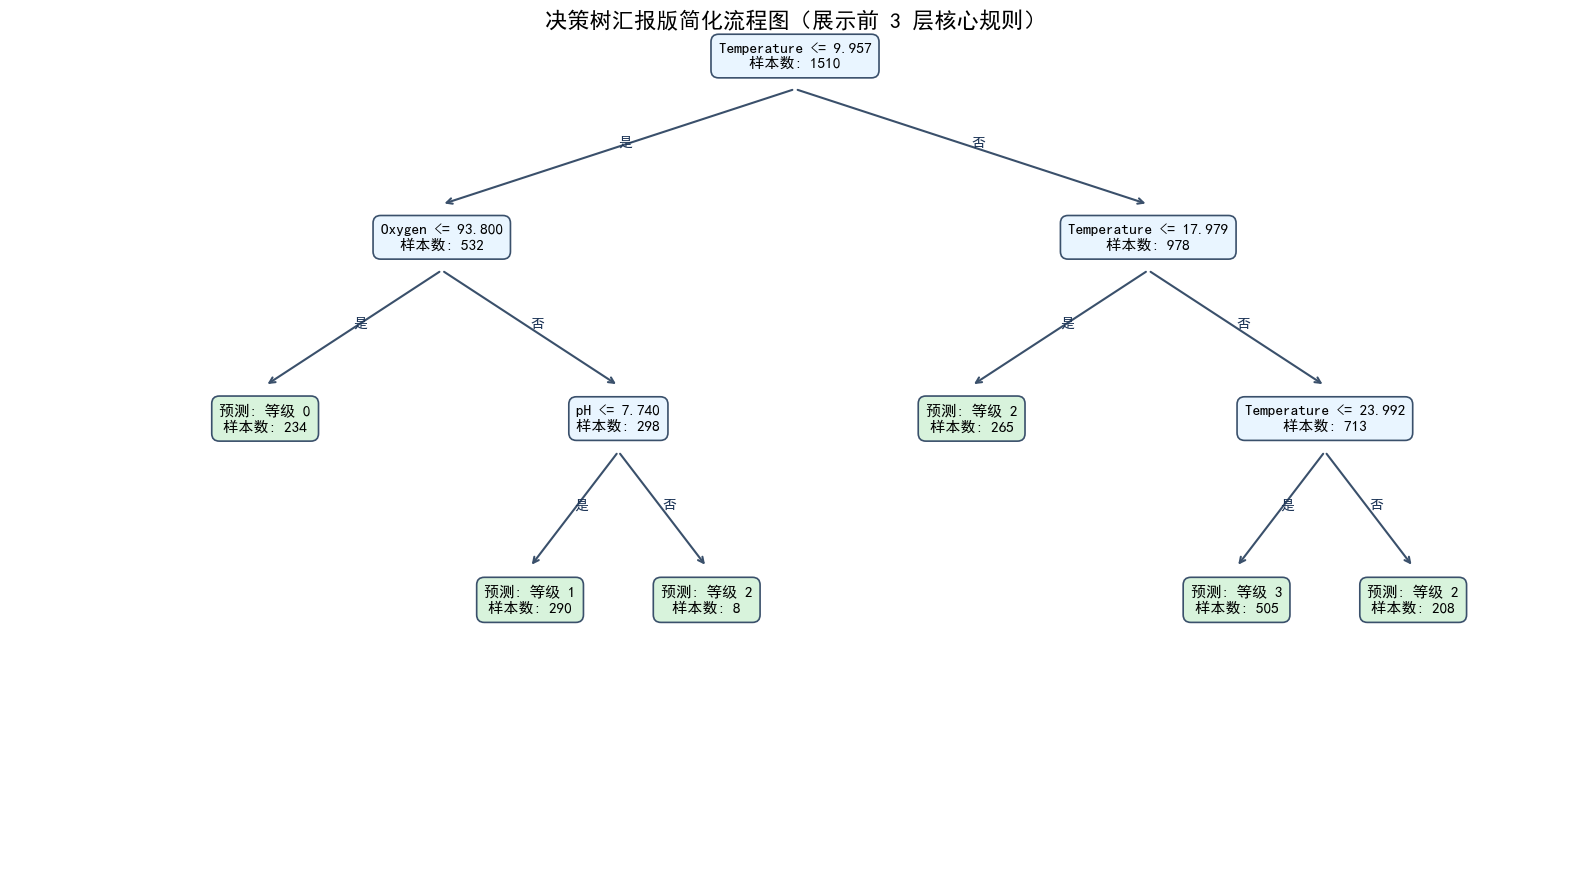

流程图已保存: 决策树汇报版流程图.png


In [17]:
# 14. 生成决策树规则汇总表和汇报版流程图
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, _tree

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

if 'rule_tree' not in globals() or 'rule_features' not in globals() or 'y_rules' not in globals():
    df_rules = pd.read_csv('waterdata_ready_for_ml_weighted_no_unit.csv')
    rule_features = ['Depth', 'Temperature', 'Salinity', 'Oxygen', 'pH', 'DO_mgL']
    X_rules = df_rules[rule_features].copy()
    if df_rules['QualityLevel'].dtype == 'object':
        label_encoder_rules = LabelEncoder()
        y_rules = label_encoder_rules.fit_transform(df_rules['QualityLevel'])
    else:
        y_rules = df_rules['QualityLevel'].to_numpy()
    rule_tree = DecisionTreeClassifier(random_state=42)
    rule_tree.fit(X_rules, y_rules)

class_names = [f'等级 {cls}' for cls in np.unique(y_rules)]
tree_struct = rule_tree.tree_

def collect_leaf_rules(node_id=0, conditions=None, records=None):
    if conditions is None:
        conditions = []
    if records is None:
        records = []

    feature_index = tree_struct.feature[node_id]
    sample_count = int(tree_struct.n_node_samples[node_id])
    predicted_class = int(np.argmax(tree_struct.value[node_id][0]))

    if feature_index == _tree.TREE_UNDEFINED:
        records.append({
            '叶节点': len(records) + 1,
            '规则条件': ' 且 '.join(conditions) if conditions else '全部样本',
            '预测等级': predicted_class,
            '样本数': sample_count
        })
        return records

    feature_name = rule_features[feature_index]
    threshold = float(tree_struct.threshold[node_id])

    left_conditions = conditions + [f'{feature_name} <= {threshold:.3f}']
    right_conditions = conditions + [f'{feature_name} > {threshold:.3f}']

    collect_leaf_rules(tree_struct.children_left[node_id], left_conditions, records)
    collect_leaf_rules(tree_struct.children_right[node_id], right_conditions, records)
    return records

leaf_rules_df = pd.DataFrame(collect_leaf_rules()).sort_values(['样本数', '预测等级'], ascending=[False, True])
display(leaf_rules_df)

leaf_rules_path = '决策树规则汇总表.csv'
leaf_rules_df.to_csv(leaf_rules_path, index=False, encoding='utf-8-sig')
print(f'规则汇总表已保存: {leaf_rules_path}')

max_display_depth = 3
positions = {}
node_labels = {}
edge_labels = []

def layout_tree(node_id, depth, left_bound, right_bound):
    x = (left_bound + right_bound) / 2
    y = 1 - depth * 0.22
    positions[node_id] = (x, y)

    feature_index = tree_struct.feature[node_id]
    sample_count = int(tree_struct.n_node_samples[node_id])
    predicted_class = int(np.argmax(tree_struct.value[node_id][0]))

    if feature_index == _tree.TREE_UNDEFINED or depth >= max_display_depth:
        node_labels[node_id] = f'预测: 等级 {predicted_class}\n样本数: {sample_count}'
        return

    feature_name = rule_features[feature_index]
    threshold = float(tree_struct.threshold[node_id])
    node_labels[node_id] = f'{feature_name} <= {threshold:.3f}\n样本数: {sample_count}'

    left_id = tree_struct.children_left[node_id]
    right_id = tree_struct.children_right[node_id]

    layout_tree(left_id, depth + 1, left_bound, x)
    layout_tree(right_id, depth + 1, x, right_bound)

    edge_labels.append((node_id, left_id, '是'))
    edge_labels.append((node_id, right_id, '否'))

layout_tree(0, 0, 0.05, 0.95)

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

for node_id, (x, y) in positions.items():
    feature_index = tree_struct.feature[node_id]
    is_leaf_or_truncated = feature_index == _tree.TREE_UNDEFINED or (1 - y) / 0.22 >= max_display_depth
    box_facecolor = '#d8f3dc' if is_leaf_or_truncated else '#e9f5ff'
    ax.text(
        x,
        y,
        node_labels[node_id],
        ha='center',
        va='center',
        fontsize=11,
        bbox=dict(boxstyle='round,pad=0.5', facecolor=box_facecolor, edgecolor='#3a506b', linewidth=1.2)
    )

for parent_id, child_id, label in edge_labels:
    x1, y1 = positions[parent_id]
    x2, y2 = positions[child_id]
    ax.annotate('', xy=(x2, y2 + 0.04), xytext=(x1, y1 - 0.04), arrowprops=dict(arrowstyle='->', color='#3a506b', lw=1.5))
    ax.text((x1 + x2) / 2, (y1 + y2) / 2, label, fontsize=10, color='#1d3557')

plt.title('决策树汇报版简化流程图（展示前 3 层核心规则）', fontsize=16, pad=20)
plt.tight_layout()
flowchart_path = '决策树汇报版流程图.png'
plt.savefig(flowchart_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'流程图已保存: {flowchart_path}')


# 15. 中间梯度模型横向比较

如果你希望在“逻辑回归”和“决策树”之间补一类表现居中的模型，用于增加实验工作量和比较层次，可以优先考察以下模型：

1. KNN：保留局部邻域信息，通常能学到一部分非线性边界，但复杂度和可解释性仍明显低于树集成模型。
2. RBF-SVM：能够拟合非线性分界，常见表现会高于逻辑回归，但不一定逼近树模型。
3. Gaussian Naive Bayes：建模假设更强，通常作为较弱但很经典的统计基线。

下面单元会统一使用 5 折分层交叉验证，筛选平均准确率位于“逻辑回归”和“决策树”之间的模型。


寻找介于逻辑回归与决策树之间的模型
        模型    准确率均值   准确率标准差   加权F1均值
       决策树 0.997351 0.002478 0.997350
    KNN-11 0.968212 0.004492 0.968163
   RBF-SVM 0.939073 0.015616 0.938523
      逻辑回归 0.829139 0.021723 0.828762
GaussianNB 0.803311 0.022998 0.790793

候选中间模型:
     模型    准确率均值   准确率标准差   加权F1均值
 KNN-11 0.968212 0.004492 0.968163
RBF-SVM 0.939073 0.015616 0.938523

推荐作为横向比较补充的模型: KNN-11
平均准确率: 0.9682 +/- 0.0045


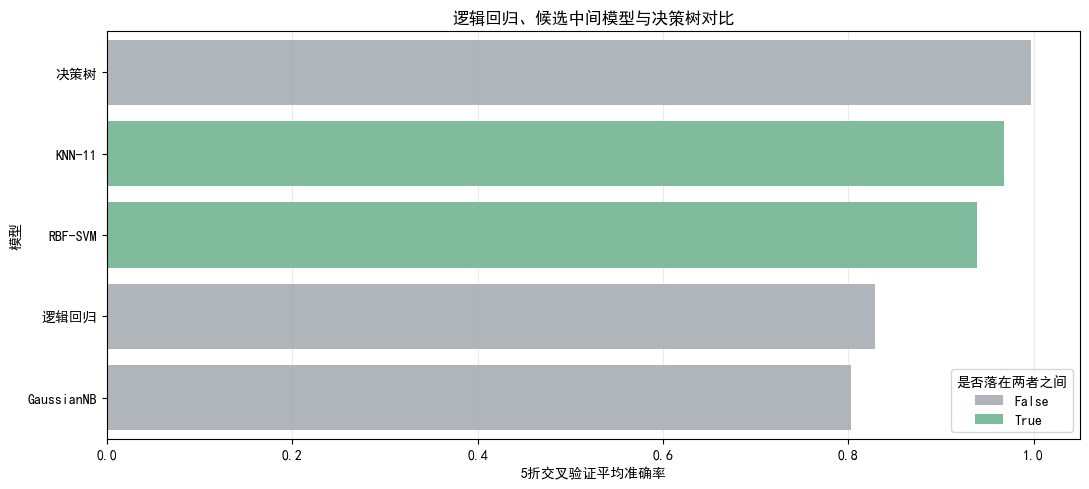

In [18]:
# 16. 寻找准确率介于逻辑回归与决策树之间的模型
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

df_mid = pd.read_csv('waterdata_ready_for_ml_weighted_no_unit.csv')
mid_features = ['Depth', 'Temperature', 'Salinity', 'Oxygen', 'pH', 'DO_mgL']
X_mid = df_mid[mid_features].copy()

if df_mid['QualityLevel'].dtype == 'object':
    label_encoder_mid = LabelEncoder()
    y_mid = label_encoder_mid.fit_transform(df_mid['QualityLevel'])
else:
    y_mid = df_mid['QualityLevel'].to_numpy()

cv_mid = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_mid = {
    'accuracy': 'accuracy',
    'f1_weighted': make_scorer(f1_score, average='weighted')
}

baseline_models = {
    '逻辑回归': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            multi_class='multinomial',
            solver='lbfgs',
            max_iter=2000,
            random_state=42
        ))
    ]),
    'KNN-11': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=11, weights='distance'))
    ]),
    'RBF-SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(C=3, kernel='rbf', gamma='scale'))
    ]),
    'GaussianNB': GaussianNB(),
    '决策树': DecisionTreeClassifier(random_state=42)
}

mid_rows = []
for model_name, estimator in baseline_models.items():
    scores = cross_validate(estimator, X_mid, y_mid, cv=cv_mid, scoring=scoring_mid, n_jobs=-1)
    mid_rows.append({
        '模型': model_name,
        '准确率均值': scores['test_accuracy'].mean(),
        '准确率标准差': scores['test_accuracy'].std(),
        '加权F1均值': scores['test_f1_weighted'].mean()
    })

mid_results_df = pd.DataFrame(mid_rows).sort_values('准确率均值', ascending=False).reset_index(drop=True)
print('\n' + '=' * 72)
print('寻找介于逻辑回归与决策树之间的模型')
print('=' * 72)
print(mid_results_df.to_string(index=False))

log_reg_acc = mid_results_df.loc[mid_results_df['模型'] == '逻辑回归', '准确率均值'].iloc[0]
tree_acc = mid_results_df.loc[mid_results_df['模型'] == '决策树', '准确率均值'].iloc[0]
bridge_df = mid_results_df[
    (mid_results_df['准确率均值'] > log_reg_acc) &
    (mid_results_df['准确率均值'] < tree_acc)
].sort_values('准确率均值', ascending=False)

print('\n候选中间模型:')
if bridge_df.empty:
    print('这组候选里没有模型稳定落在逻辑回归和决策树之间，可以继续试 MLP 或更弱的树模型。')
else:
    print(bridge_df.to_string(index=False))
    best_bridge = bridge_df.iloc[0]
    print(f"\n推荐作为横向比较补充的模型: {best_bridge['模型']}")
    print(f"平均准确率: {best_bridge['准确率均值']:.4f} +/- {best_bridge['准确率标准差']:.4f}")

plot_df = mid_results_df.copy()
plot_df['是否中间模型'] = plot_df['模型'].isin(bridge_df['模型'])

plt.figure(figsize=(11, 5))
sns.barplot(
    data=plot_df,
    x='准确率均值',
    y='模型',
    hue='是否中间模型',
    palette={True: '#74c69d', False: '#adb5bd'}
)
plt.xlim(0, 1.05)
plt.xlabel('5折交叉验证平均准确率')
plt.ylabel('模型')
plt.title('逻辑回归、候选中间模型与决策树对比')
plt.grid(axis='x', alpha=0.25)
plt.legend(title='是否落在两者之间')
plt.tight_layout()
plt.show()

# 17. 已使用模型总览：按自学顺序由简到难

为了便于自学和汇报，可以把前面用过的方法整理为 7 类模型，并按照“从最容易理解到相对更复杂”的顺序来介绍。这里把“逻辑回归 + 分组 PCA”视为逻辑回归的一种特征工程版本，而不是第 8 个全新模型。

## 1. Gaussian Naive Bayes（高斯朴素贝叶斯）

这是最适合初学者入门的概率分类模型之一。它假设在给定类别的条件下，各个特征彼此独立，并且每个特征在每一类中近似服从高斯分布。这个假设通常比较强，所以模型表达能力有限，但优点是训练速度快、公式清晰、容易解释。

在本项目中，它可以作为一个较弱但经典的统计基线，用来说明：如果模型对特征关系的刻画太粗糙，性能就会明显受限。

## 2. 逻辑回归（Logistic Regression）

逻辑回归是最经典的线性分类模型之一。它本质上是在学习一个线性决策边界，因此适合先作为“基础比较对象”。如果类别边界接近线性，逻辑回归表现通常不错；但如果边界是分段式、非线性的，它的上限就会比较明显。

你前面已经使用了两种版本：

- 原始特征逻辑回归：直接对标准化后的原始特征建模。
- 分组 PCA 逻辑回归：先把强相关特征压缩为主成分，再做逻辑回归。

这一步非常适合教学，因为它能帮助理解“模型能力”和“特征工程”是两个不同层次的问题。

## 3. KNN（K-最近邻）

KNN 是一种非常直观的邻域方法。它不急着先学出一个显式公式，而是通过“看周围最近的样本属于哪一类”来决定新样本的类别。它的思想简单，非常适合自学者理解“相似样本往往属于相似类别”这件事。

不过，KNN 对特征尺度很敏感，因此必须先做标准化；否则数值范围大的变量会主导距离计算。

## 4. RBF-SVM（带径向基核的支持向量机）

RBF-SVM 可以看成是从线性分类器迈向非线性分类器的重要一步。它通过核函数把原始特征映射到更高维空间，再在高维空间中寻找更合适的分类边界，因此能处理弯曲、复杂的分界线。

对自学者来说，它的理解门槛高于逻辑回归和 KNN，因为它不再只是“看最近邻”或“画一条直线”，而是在做更抽象的非线性边界学习。

## 5. 决策树（Decision Tree）

决策树是本项目里最重要的模型。它通过一系列“如果某个特征小于或大于某个阈值，就进入下一层”的规则进行分类，非常适合处理你这类由分段规则生成出来的标签。

它最大的优点是可解释性强：不仅能做分类，还能直接生成树结构、阈值规则、流程图和规则汇总表。对展示和汇报来说，决策树是最有优势的模型。

## 6. 随机森林（Random Forest）

随机森林可以理解为“很多棵决策树投票”的集成方法。相比单棵决策树，它通常更稳健、更不容易过拟合，但代价是可解释性下降。你能看到整体特征重要性，却不容易像单棵树那样直接讲清楚每一条决策路径。

对自学者来说，它是从“单个模型”走向“集成学习”的第一步。

## 7. XGBoost

XGBoost 是比随机森林更进一步的提升树方法。它不是简单投票，而是让后面的树专门去修正前面树的错误，因此往往能取得很强的预测性能。它在工程界和竞赛场景里都非常常见。

不过，它的参数更多、原理更复杂、调参成本更高，所以更适合放在学习顺序的最后。

## 模型对比表（突出最佳模型）

| 学习顺序 | 模型类别 | 代表模型 | 主要特点 | 当前任务表现概括 | 是否适合汇报主模型 |
|---|---|---|---|---|---|
| 1 | 概率模型 | Gaussian Naive Bayes | 假设强、速度快、适合做弱基线 | 偏弱，低于逻辑回归 | 否 |
| 2 | 线性模型 | 逻辑回归 | 结构清晰、易解释，但只能学线性边界 | 中等，适合作为基础参照 | 否 |
| 3 | 邻域方法 | KNN | 直观、非参数、依赖距离 | 明显强于逻辑回归 | 可作为补充比较 |
| 4 | 核方法 | RBF-SVM | 可拟合非线性边界，表达能力更强 | 介于逻辑回归和决策树之间 | 可作为补充比较 |
| 5 | 规则模型 | 决策树 | 规则清晰、可视化强、最适合分段阈值任务 | **综合表现最好，且最易解释** | **是** |
| 6 | 集成树模型 | 随机森林 | 更稳健，但解释性下降 | 很强，但没有明显超过决策树 | 可作为扩展对照 |
| 7 | 提升树模型 | XGBoost | 性能强、参数多、复杂度高 | 很强，但本任务中仍未优于决策树 | 可作为扩展对照 |

## 为什么最终突出决策树

从你前面的实验结果看，决策树并不是最复杂的模型，但却是最适合这份数据的模型。原因主要有三点：

1. 当前标签 QualityLevel 本身就来自分段阈值和规则组合，因此决策树天然匹配这种结构。
2. 决策树的准确率已经达到最高水平附近，而随机森林和 XGBoost 并没有带来显著增益。
3. 决策树可以直接展示规则、阈值、流程图和叶节点说明，这一点远强于 KNN、RBF-SVM、随机森林和 XGBoost。

因此，如果目标是“兼顾结果、解释性和汇报效果”，本项目最值得作为最终主模型展示的方法仍然是决策树。

In [19]:
# 18. 七个模型交叉验证结果汇总表（逻辑回归使用分组 PCA 后结果）
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


class GroupedPCATransformer(BaseEstimator, TransformerMixin):
    def __init__(self, group1, group2, independent_features):
        self.group1 = group1
        self.group2 = group2
        self.independent_features = independent_features

    def fit(self, X, y=None):
        self.scaler_group1_ = StandardScaler()
        self.scaler_group2_ = StandardScaler()
        self.pca_group1_ = PCA(n_components=1)
        self.pca_group2_ = PCA(n_components=1)

        self.pca_group1_.fit(self.scaler_group1_.fit_transform(X[self.group1]))
        self.pca_group2_.fit(self.scaler_group2_.fit_transform(X[self.group2]))
        return self

    def transform(self, X):
        transformed = pd.DataFrame(index=X.index)
        transformed['PC1_oxygen'] = self.pca_group1_.transform(
            self.scaler_group1_.transform(X[self.group1])
        ).ravel()
        transformed['PC1_temp_pH'] = self.pca_group2_.transform(
            self.scaler_group2_.transform(X[self.group2])
        ).ravel()

        for feature in self.independent_features:
            transformed[feature] = X[feature].values
        return transformed


df_summary = pd.read_csv('waterdata_ready_for_ml_weighted_no_unit.csv')
summary_features = ['Depth', 'Temperature', 'Salinity', 'Oxygen', 'pH', 'DO_mgL']
X_summary = df_summary[summary_features].copy()

if df_summary['QualityLevel'].dtype == 'object':
    label_encoder_summary = LabelEncoder()
    y_summary = label_encoder_summary.fit_transform(df_summary['QualityLevel'])
else:
    y_summary = df_summary['QualityLevel'].to_numpy()

cv_summary = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_summary = {
    'accuracy': 'accuracy',
    'f1_weighted': make_scorer(f1_score, average='weighted')
}

grouped_pca_log_reg = Pipeline([
    ('grouped_pca', GroupedPCATransformer(
        group1=['Oxygen', 'DO_mgL'],
        group2=['Temperature', 'pH'],
        independent_features=['Depth', 'Salinity']
    )),
    ('model', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=2000,
        random_state=42
    ))
])

seven_models = {
    'Gaussian Naive Bayes': GaussianNB(),
    '逻辑回归（分组PCA）': grouped_pca_log_reg,
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=11, weights='distance'))
    ]),
    'RBF-SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(C=3, kernel='rbf', gamma='scale'))
    ]),
    '决策树': DecisionTreeClassifier(random_state=42),
    '随机森林': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        objective='multi:softprob',
        num_class=len(np.unique(y_summary)),
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        tree_method='hist',
        eval_metric='mlogloss'
    )
}

summary_rows = []
for model_name, estimator in seven_models.items():
    scores = cross_validate(
        estimator,
        X_summary,
        y_summary,
        cv=cv_summary,
        scoring=scoring_summary,
        n_jobs=-1
    )
    summary_rows.append({
        '模型': model_name,
        '准确率均值': round(scores['test_accuracy'].mean(), 4),
        '准确率标准差': round(scores['test_accuracy'].std(), 4),
        '加权F1均值': round(scores['test_f1_weighted'].mean(), 4)
    })

seven_model_summary_df = pd.DataFrame(summary_rows).sort_values('准确率均值', ascending=False).reset_index(drop=True)
display(seven_model_summary_df)

summary_csv_path = '七个模型交叉验证结果汇总表.csv'
seven_model_summary_df.to_csv(summary_csv_path, index=False, encoding='utf-8-sig')
print(f'汇总表已保存: {summary_csv_path}')

,模型,准确率均值,准确率标准差,加权F1均值
0,决策树,0.9974,0.0025,0.9974
1,随机森林,0.9954,0.0026,0.9954
2,XGBoost,0.9921,0.0026,0.9921
3,KNN,0.9682,0.0045,0.9682
4,RBF-SVM,0.9391,0.0156,0.9385
5,逻辑回归（分组PCA）,0.8066,0.0250,0.8062
6,Gaussian Naive Bayes,0.8033,0.0230,0.7908


汇总表已保存: 七个模型交叉验证结果汇总表.csv


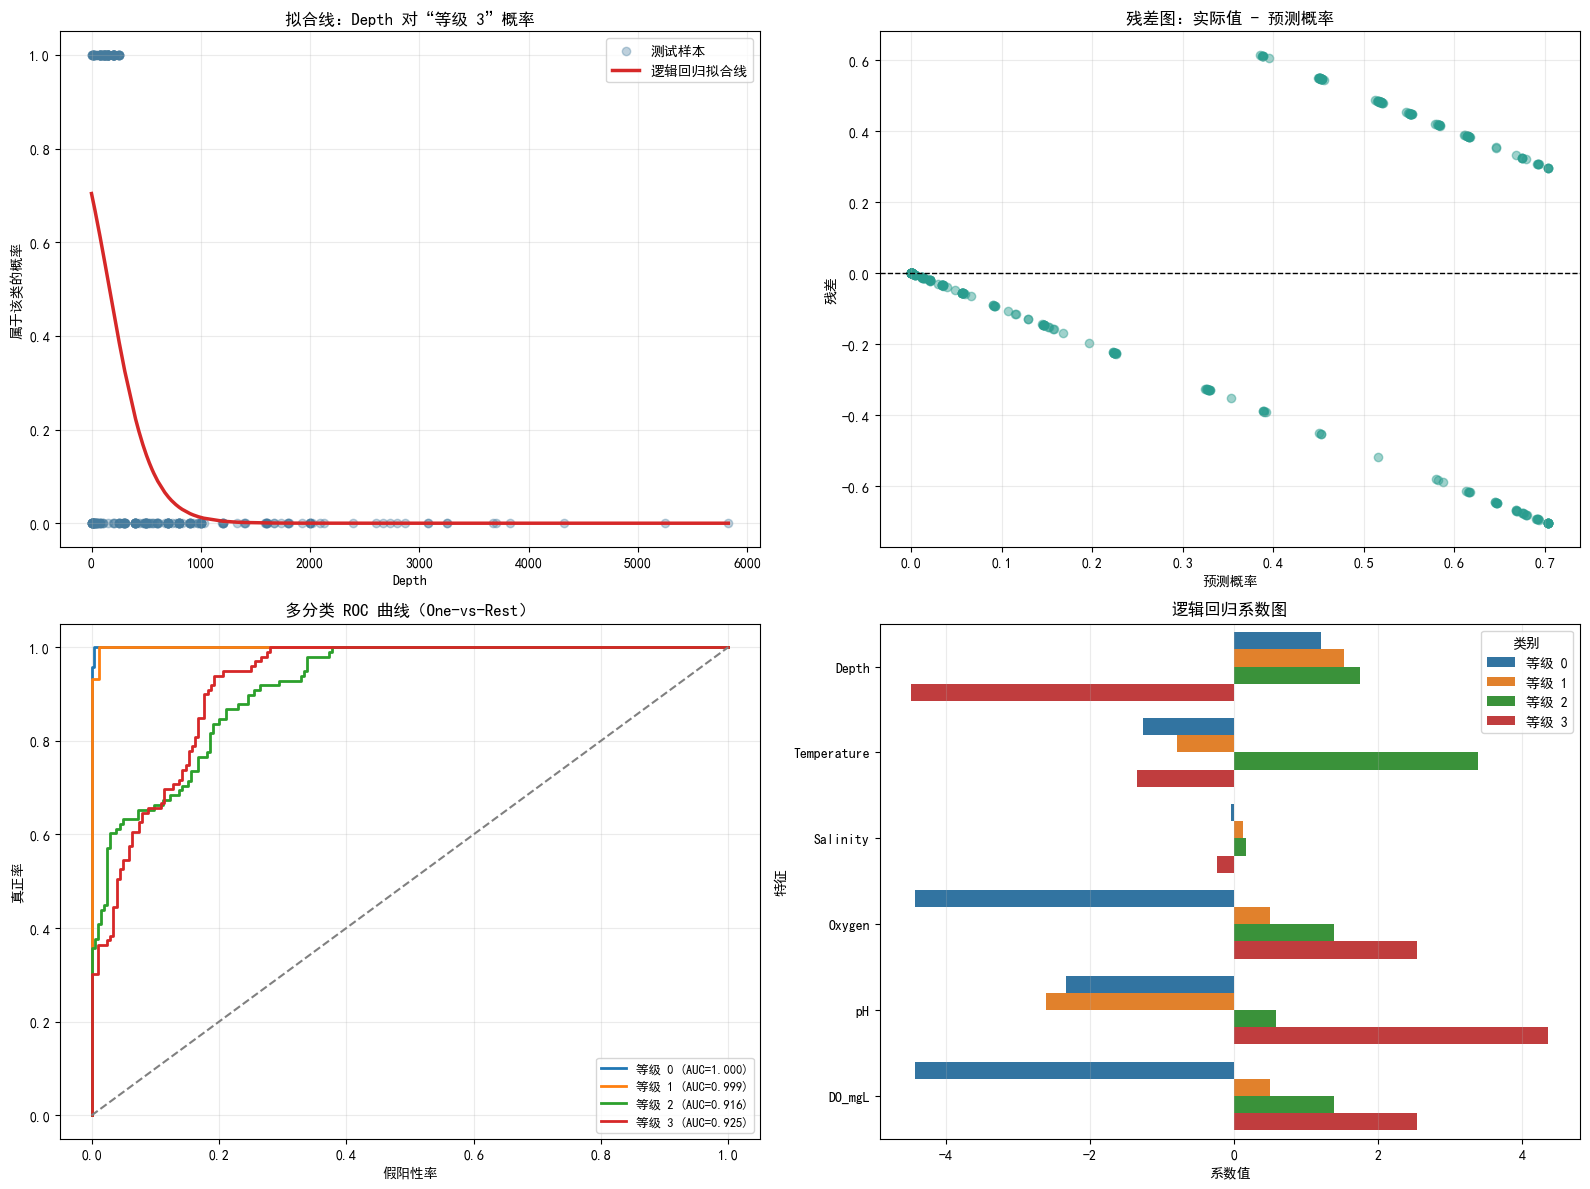

用于拟合线与残差图的目标类别: 等级 3
对应的最强特征: Depth


In [20]:
# 19. 逻辑回归：拟合线、残差、ROC、系数图
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

if 'df' in globals() and 'QualityLevel' in df.columns:
    df_lr = df.copy()
else:
    df_lr = pd.read_csv('waterdata_ready_for_ml_weighted_no_unit.csv')

lr_features = ['Depth', 'Temperature', 'Salinity', 'Oxygen', 'pH', 'DO_mgL']
X_lr = df_lr[lr_features].copy()

if df_lr['QualityLevel'].dtype == 'object':
    label_encoder_lr = LabelEncoder()
    y_lr = label_encoder_lr.fit_transform(df_lr['QualityLevel'])
    class_labels_lr = [str(name) for name in label_encoder_lr.classes_]
else:
    y_lr = df_lr['QualityLevel'].to_numpy()
    class_labels_lr = [f'等级 {cls}' for cls in np.unique(y_lr)]

y_lr = np.asarray(y_lr)
classes_lr = np.unique(y_lr)
class_to_idx_lr = {cls: idx for idx, cls in enumerate(classes_lr)}

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42, stratify=y_lr
)

scaler_lr = StandardScaler()
X_train_lr_scaled = scaler_lr.fit_transform(X_train_lr)
X_test_lr_scaled = scaler_lr.transform(X_test_lr)

multi_lr = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=3000,
    random_state=42
)
multi_lr.fit(X_train_lr_scaled, y_train_lr)
y_prob_lr = multi_lr.predict_proba(X_test_lr_scaled)

major_class_lr = int(pd.Series(y_train_lr).value_counts().idxmax())
major_class_idx_lr = class_to_idx_lr[major_class_lr]
top_feature_idx_lr = int(np.argmax(np.abs(multi_lr.coef_[major_class_idx_lr])))
top_feature_name_lr = lr_features[top_feature_idx_lr]

y_train_binary_lr = (y_train_lr == major_class_lr).astype(int)
y_test_binary_lr = (y_test_lr == major_class_lr).astype(int)

x_train_single_lr = X_train_lr[[top_feature_name_lr]].copy()
x_test_single_lr = X_test_lr[[top_feature_name_lr]].copy()
single_scaler_lr = StandardScaler()
x_train_single_lr_scaled = single_scaler_lr.fit_transform(x_train_single_lr)
x_test_single_lr_scaled = single_scaler_lr.transform(x_test_single_lr)

binary_lr = LogisticRegression(solver='lbfgs', max_iter=3000, random_state=42)
binary_lr.fit(x_train_single_lr_scaled, y_train_binary_lr)

single_prob_lr = binary_lr.predict_proba(x_test_single_lr_scaled)[:, 1]
residuals_lr = y_test_binary_lr - single_prob_lr
sorted_idx_lr = np.argsort(x_test_single_lr[top_feature_name_lr].to_numpy())
x_sorted_lr = x_test_single_lr.iloc[sorted_idx_lr, 0].to_numpy()
prob_sorted_lr = single_prob_lr[sorted_idx_lr]

y_test_bin_lr = label_binarize(y_test_lr, classes=classes_lr)
if y_test_bin_lr.shape[1] == 1:
    y_test_bin_lr = np.hstack([1 - y_test_bin_lr, y_test_bin_lr])
    y_prob_plot_lr = np.column_stack([1 - y_prob_lr[:, 0], y_prob_lr[:, 0]])
    roc_labels_lr = ['非目标类', class_labels_lr[0]]
else:
    y_prob_plot_lr = y_prob_lr
    roc_labels_lr = class_labels_lr

coef_plot_lr = (
    pd.DataFrame(multi_lr.coef_, columns=lr_features, index=class_labels_lr)
    .reset_index(names='类别')
    .melt(id_vars='类别', var_name='特征', value_name='系数')
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].scatter(
    x_test_single_lr[top_feature_name_lr],
    y_test_binary_lr,
    alpha=0.35,
    color='#457b9d',
    label='测试样本'
)
axes[0, 0].plot(x_sorted_lr, prob_sorted_lr, color='#d62828', linewidth=2.5, label='逻辑回归拟合线')
axes[0, 0].set_title(f'拟合线：{top_feature_name_lr} 对“{class_labels_lr[major_class_idx_lr]}”概率')
axes[0, 0].set_xlabel(top_feature_name_lr)
axes[0, 0].set_ylabel('属于该类的概率')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.25)

axes[0, 1].scatter(single_prob_lr, residuals_lr, alpha=0.45, color='#2a9d8f')
axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0, 1].set_title('残差图：实际值 - 预测概率')
axes[0, 1].set_xlabel('预测概率')
axes[0, 1].set_ylabel('残差')
axes[0, 1].grid(alpha=0.25)

for idx in range(y_test_bin_lr.shape[1]):
    fpr_lr, tpr_lr, _ = roc_curve(y_test_bin_lr[:, idx], y_prob_plot_lr[:, idx])
    auc_lr = auc(fpr_lr, tpr_lr)
    axes[1, 0].plot(fpr_lr, tpr_lr, linewidth=2, label=f'{roc_labels_lr[idx]} (AUC={auc_lr:.3f})')
axes[1, 0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1, 0].set_title('多分类 ROC 曲线（One-vs-Rest）')
axes[1, 0].set_xlabel('假阳性率')
axes[1, 0].set_ylabel('真正率')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(alpha=0.25)

sns.barplot(data=coef_plot_lr, x='系数', y='特征', hue='类别', orient='h', ax=axes[1, 1])
axes[1, 1].set_title('逻辑回归系数图')
axes[1, 1].set_xlabel('系数值')
axes[1, 1].set_ylabel('特征')
axes[1, 1].grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

print(f'用于拟合线与残差图的目标类别: {class_labels_lr[major_class_idx_lr]}')
print(f'对应的最强特征: {top_feature_name_lr}')

### 图表说明

1. 拟合线图：展示逻辑回归在“最强特征”上的概率变化趋势。横轴是该特征取值，纵轴是样本属于目标类别的预测概率；曲线越陡，说明该特征对该类别的区分作用越明显。
2. 残差图：展示“实际标签减去预测概率”后的误差分布。如果点大多围绕 0 且没有明显结构，说明模型概率输出较稳定；若某些概率区间残差集中偏正或偏负，说明这些区间存在系统性高估或低估。
3. ROC 图：展示各类别的一对其余分类能力。曲线越靠近左上角、AUC 越大，说明该类别越容易被逻辑回归区分。
4. 系数图：展示不同类别下各特征的回归系数方向和大小。正系数表示该特征增大时更倾向于该类别，绝对值越大说明影响越强。

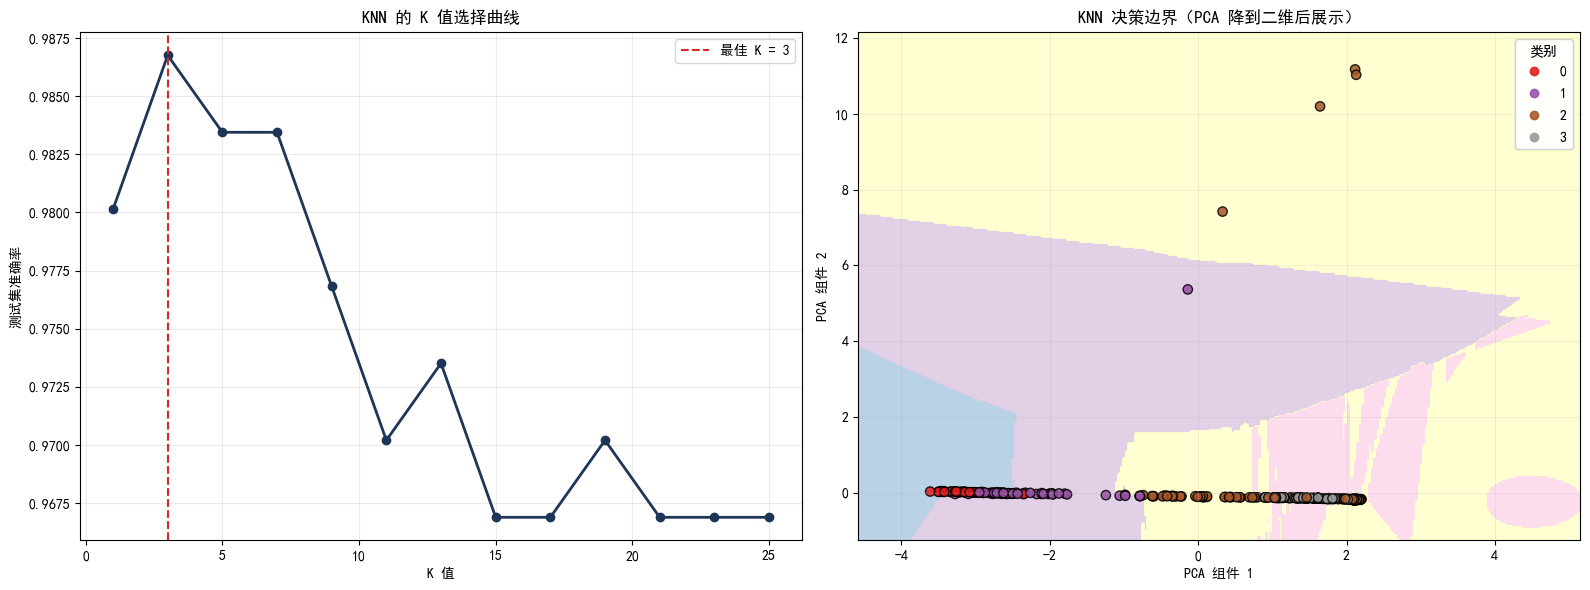

最佳 K 值: 3
对应测试集准确率: 0.9868


In [21]:
# 20. KNN：K 曲线、决策边界
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

if 'df' in globals() and 'QualityLevel' in df.columns:
    df_knn = df.copy()
else:
    df_knn = pd.read_csv('waterdata_ready_for_ml_weighted_no_unit.csv')

knn_features = ['Depth', 'Temperature', 'Salinity', 'Oxygen', 'pH', 'DO_mgL']
X_knn = df_knn[knn_features].copy()

if df_knn['QualityLevel'].dtype == 'object':
    label_encoder_knn = LabelEncoder()
    y_knn = label_encoder_knn.fit_transform(df_knn['QualityLevel'])
else:
    y_knn = df_knn['QualityLevel'].to_numpy()

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn, y_knn, test_size=0.2, random_state=42, stratify=y_knn
)

scaler_knn = StandardScaler()
X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)
X_test_knn_scaled = scaler_knn.transform(X_test_knn)

k_values = list(range(1, 26, 2))
test_scores_knn = []
for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_model.fit(X_train_knn_scaled, y_train_knn)
    test_scores_knn.append(accuracy_score(y_test_knn, knn_model.predict(X_test_knn_scaled)))

best_k_knn = k_values[int(np.argmax(test_scores_knn))]

pca_knn = PCA(n_components=2)
X_train_knn_2d = pca_knn.fit_transform(X_train_knn_scaled)
X_test_knn_2d = pca_knn.transform(X_test_knn_scaled)

knn_boundary = KNeighborsClassifier(n_neighbors=best_k_knn, weights='distance')
knn_boundary.fit(X_train_knn_2d, y_train_knn)

x_min_knn, x_max_knn = X_train_knn_2d[:, 0].min() - 1.0, X_train_knn_2d[:, 0].max() + 1.0
y_min_knn, y_max_knn = X_train_knn_2d[:, 1].min() - 1.0, X_train_knn_2d[:, 1].max() + 1.0
xx_knn, yy_knn = np.meshgrid(
    np.linspace(x_min_knn, x_max_knn, 300),
    np.linspace(y_min_knn, y_max_knn, 300)
)
grid_knn = np.c_[xx_knn.ravel(), yy_knn.ravel()]
zz_knn = knn_boundary.predict(grid_knn).reshape(xx_knn.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(k_values, test_scores_knn, marker='o', color='#1d3557', linewidth=2)
axes[0].axvline(best_k_knn, color='#d62828', linestyle='--', label=f'最佳 K = {best_k_knn}')
axes[0].set_title('KNN 的 K 值选择曲线')
axes[0].set_xlabel('K 值')
axes[0].set_ylabel('测试集准确率')
axes[0].grid(alpha=0.25)
axes[0].legend()

contour_knn = axes[1].contourf(xx_knn, yy_knn, zz_knn, levels=np.arange(len(np.unique(y_knn)) + 1) - 0.5, cmap='Pastel1', alpha=0.9)
scatter_knn = axes[1].scatter(
    X_test_knn_2d[:, 0],
    X_test_knn_2d[:, 1],
    c=y_test_knn,
    cmap='Set1',
    edgecolor='black',
    s=45,
    alpha=0.85
)
axes[1].set_title('KNN 决策边界（PCA 降到二维后展示）')
axes[1].set_xlabel('PCA 组件 1')
axes[1].set_ylabel('PCA 组件 2')
axes[1].grid(alpha=0.2)
legend_knn = axes[1].legend(*scatter_knn.legend_elements(), title='类别', loc='best')
axes[1].add_artist(legend_knn)

plt.tight_layout()
plt.show()

print(f'最佳 K 值: {best_k_knn}')
print(f'对应测试集准确率: {max(test_scores_knn):.4f}')

### 图表说明

1. K 曲线：展示不同 K 值下 KNN 在测试集上的准确率变化，用来判断邻居数太小是否容易过拟合、太大是否容易欠拟合。峰值附近的 K 值通常是更合适的选择。
2. 决策边界图：展示 KNN 在二维 PCA 空间中的分类区域。背景颜色表示模型预测类别，散点表示测试样本；如果大多数样本点落在与自身颜色一致的区域内，说明分类边界与数据分布较匹配。

前文已经画过决策树树图与决策树特征重要性，这个代码块只补随机森林必须图表。


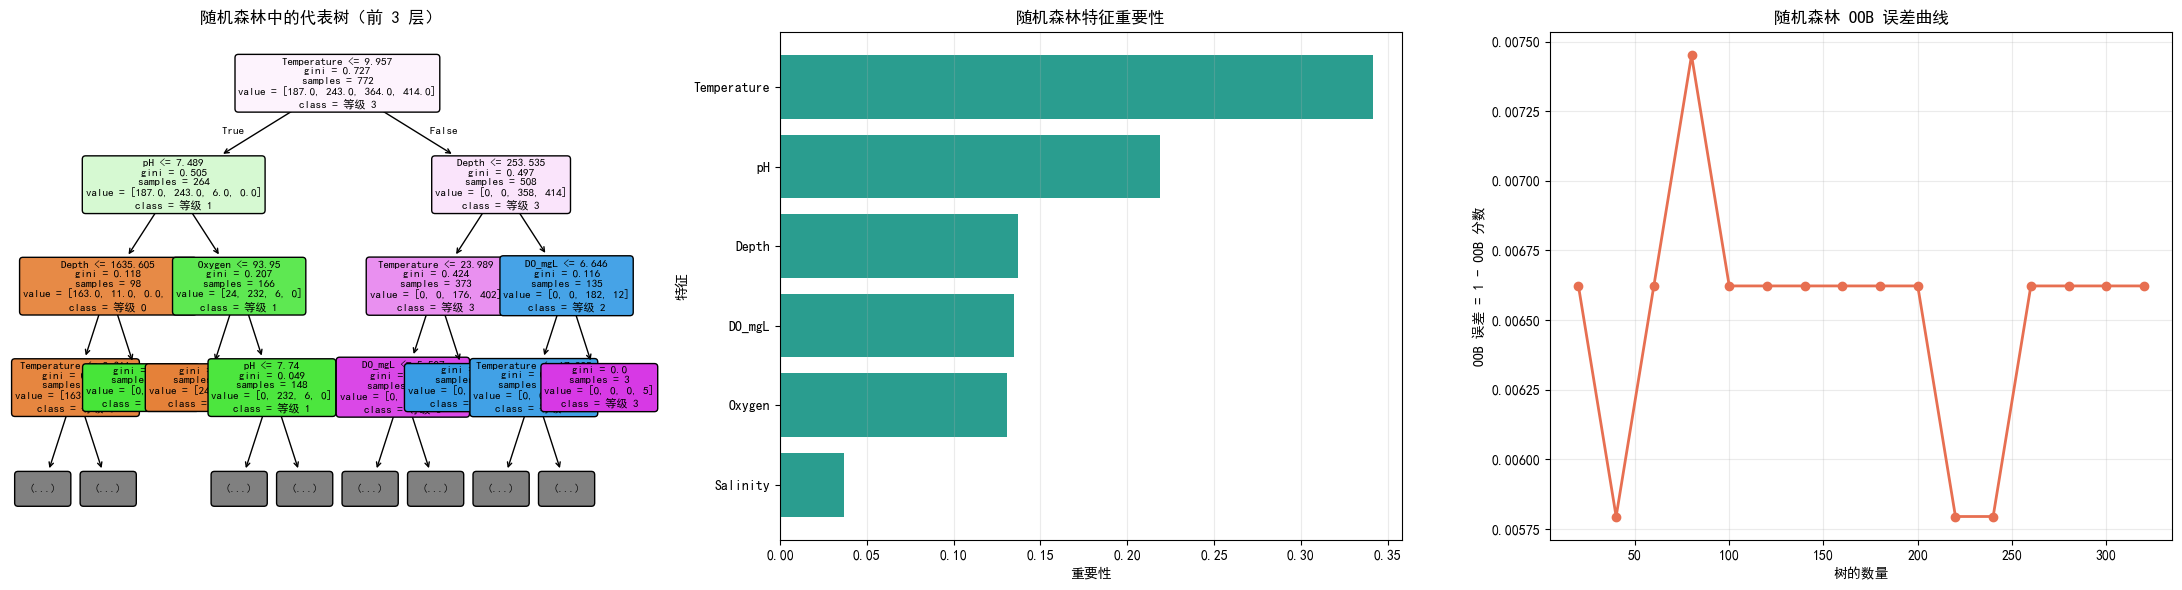

随机森林测试集准确率: 0.9934
随机森林 OOB 分数: 0.9934


In [22]:
# 21. 决策树 / 随机森林：补充森林树图、特征重要性、OOB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

if 'df' in globals() and 'QualityLevel' in df.columns:
    df_rf = df.copy()
else:
    df_rf = pd.read_csv('waterdata_ready_for_ml_weighted_no_unit.csv')

rf_features = ['Depth', 'Temperature', 'Salinity', 'Oxygen', 'pH', 'DO_mgL']
X_rf = df_rf[rf_features].copy()

if df_rf['QualityLevel'].dtype == 'object':
    label_encoder_rf = LabelEncoder()
    y_rf = label_encoder_rf.fit_transform(df_rf['QualityLevel'])
    rf_class_names = [str(name) for name in label_encoder_rf.classes_]
else:
    y_rf = df_rf['QualityLevel'].to_numpy()
    rf_class_names = [f'等级 {cls}' for cls in np.unique(y_rf)]

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf
)

print('前文已经画过决策树树图与决策树特征重要性，这个代码块只补随机森林必须图表。')

rf_model = RandomForestClassifier(
    n_estimators=300,
    oob_score=True,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_rf, y_train_rf)
rf_pred = rf_model.predict(X_test_rf)

n_tree_values = list(range(20, 321, 20))
oob_errors = []
rf_oob = RandomForestClassifier(
    n_estimators=20,
    warm_start=True,
    oob_score=True,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
for n_trees in n_tree_values:
    rf_oob.set_params(n_estimators=n_trees)
    rf_oob.fit(X_train_rf, y_train_rf)
    oob_errors.append(1 - rf_oob.oob_score_)

importance_order_rf = np.argsort(rf_model.feature_importances_)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

plot_tree(
    rf_model.estimators_[0],
    max_depth=3,
    feature_names=rf_features,
    class_names=rf_class_names,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=axes[0]
)
axes[0].set_title('随机森林中的代表树（前 3 层）')

axes[1].barh(
    np.array(rf_features)[importance_order_rf],
    rf_model.feature_importances_[importance_order_rf],
    color='#2a9d8f'
)
axes[1].set_title('随机森林特征重要性')
axes[1].set_xlabel('重要性')
axes[1].set_ylabel('特征')
axes[1].grid(axis='x', alpha=0.25)

axes[2].plot(n_tree_values, oob_errors, marker='o', color='#e76f51', linewidth=2)
axes[2].set_title('随机森林 OOB 误差曲线')
axes[2].set_xlabel('树的数量')
axes[2].set_ylabel('OOB 误差 = 1 - OOB 分数')
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f'随机森林测试集准确率: {accuracy_score(y_test_rf, rf_pred):.4f}')
print(f'随机森林 OOB 分数: {rf_model.oob_score_:.4f}')

### 图表说明

1. 代表树图：展示随机森林中一棵代表性子树的前 3 层分裂规则，用来直观看到森林内部单棵树是如何按阈值切分样本的。
2. 特征重要性图：展示随机森林综合所有树之后对各特征的平均贡献。条形越长，说明该特征在整体分类中越关键。
3. OOB 误差曲线：展示随着树数量增加，袋外误差如何变化。若曲线逐步下降后趋于平稳，说明森林规模已经足够，继续增加树的收益会变小。

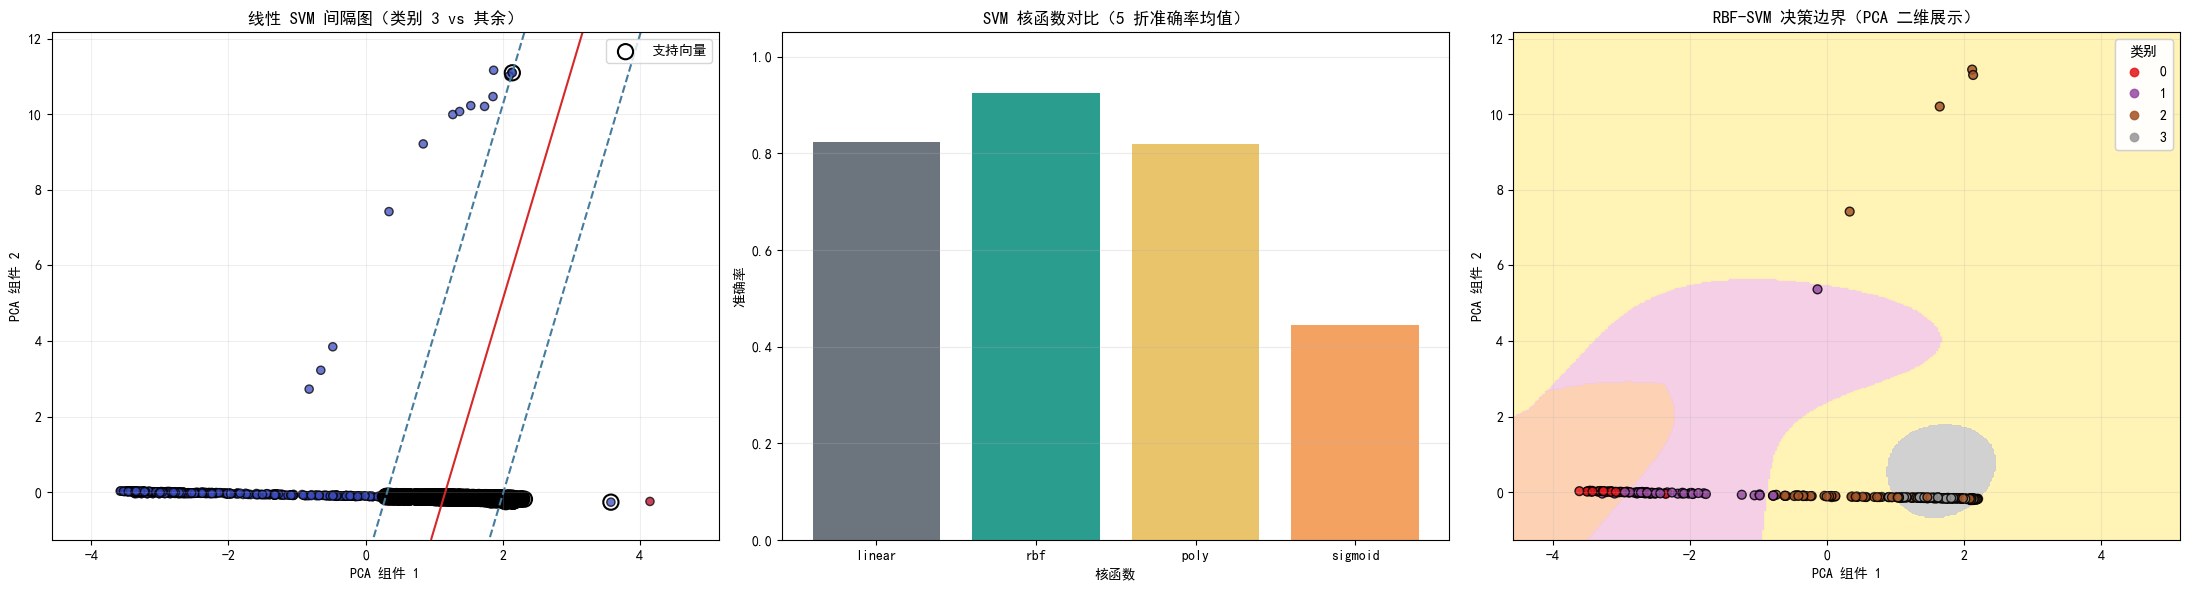

核函数平均准确率：
linear: 0.8232
rbf: 0.9252
poly: 0.8192
sigmoid: 0.4457


In [23]:
# 22. SVM：间隔图、核函数对比、决策边界
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

if 'df' in globals() and 'QualityLevel' in df.columns:
    df_svm = df.copy()
else:
    df_svm = pd.read_csv('waterdata_ready_for_ml_weighted_no_unit.csv')

svm_features = ['Depth', 'Temperature', 'Salinity', 'Oxygen', 'pH', 'DO_mgL']
X_svm = df_svm[svm_features].copy()

if df_svm['QualityLevel'].dtype == 'object':
    label_encoder_svm = LabelEncoder()
    y_svm = label_encoder_svm.fit_transform(df_svm['QualityLevel'])
else:
    y_svm = df_svm['QualityLevel'].to_numpy()

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm, y_svm, test_size=0.2, random_state=42, stratify=y_svm
)

major_class_svm = int(pd.Series(y_train_svm).value_counts().idxmax())
y_train_binary_svm = (y_train_svm == major_class_svm).astype(int)

scaler_svm = StandardScaler()
X_train_svm_scaled = scaler_svm.fit_transform(X_train_svm)
X_test_svm_scaled = scaler_svm.transform(X_test_svm)

pca_svm = PCA(n_components=2)
X_train_svm_2d = pca_svm.fit_transform(X_train_svm_scaled)
X_test_svm_2d = pca_svm.transform(X_test_svm_scaled)

linear_margin_svm = SVC(kernel='linear', C=1.5)
linear_margin_svm.fit(X_train_svm_2d, y_train_binary_svm)

kernel_models = {
    'linear': Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='linear', C=1.5))]),
    'rbf': Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='rbf', C=3, gamma='scale'))]),
    'poly': Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='poly', degree=3, C=2, gamma='scale'))]),
    'sigmoid': Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='sigmoid', C=2, gamma='scale'))])
}

kernel_scores = []
for kernel_name, estimator in kernel_models.items():
    scores = cross_val_score(estimator, X_svm, y_svm, cv=5, scoring='accuracy', n_jobs=-1)
    kernel_scores.append((kernel_name, scores.mean()))

rbf_boundary_svm = SVC(kernel='rbf', C=3, gamma='scale', decision_function_shape='ovr')
rbf_boundary_svm.fit(X_train_svm_2d, y_train_svm)

x_min_svm, x_max_svm = X_train_svm_2d[:, 0].min() - 1.0, X_train_svm_2d[:, 0].max() + 1.0
y_min_svm, y_max_svm = X_train_svm_2d[:, 1].min() - 1.0, X_train_svm_2d[:, 1].max() + 1.0
xx_svm, yy_svm = np.meshgrid(
    np.linspace(x_min_svm, x_max_svm, 350),
    np.linspace(y_min_svm, y_max_svm, 350)
)
grid_svm = np.c_[xx_svm.ravel(), yy_svm.ravel()]

margin_values_svm = linear_margin_svm.decision_function(grid_svm).reshape(xx_svm.shape)
boundary_values_svm = rbf_boundary_svm.predict(grid_svm).reshape(xx_svm.shape)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

axes[0].contour(xx_svm, yy_svm, margin_values_svm, levels=[-1, 0, 1], colors=['#457b9d', '#d62828', '#457b9d'], linestyles=['--', '-', '--'])
axes[0].scatter(
    X_train_svm_2d[:, 0],
    X_train_svm_2d[:, 1],
    c=y_train_binary_svm,
    cmap='coolwarm',
    s=35,
    alpha=0.75,
    edgecolor='black'
)
axes[0].scatter(
    linear_margin_svm.support_vectors_[:, 0],
    linear_margin_svm.support_vectors_[:, 1],
    s=120,
    facecolors='none',
    edgecolors='black',
    linewidths=1.5,
    label='支持向量'
)
axes[0].set_title(f'线性 SVM 间隔图（类别 {major_class_svm} vs 其余）')
axes[0].set_xlabel('PCA 组件 1')
axes[0].set_ylabel('PCA 组件 2')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.2)

kernel_names_svm = [item[0] for item in kernel_scores]
kernel_acc_svm = [item[1] for item in kernel_scores]
axes[1].bar(kernel_names_svm, kernel_acc_svm, color=['#6c757d', '#2a9d8f', '#e9c46a', '#f4a261'])
axes[1].set_ylim(0, 1.05)
axes[1].set_title('SVM 核函数对比（5 折准确率均值）')
axes[1].set_xlabel('核函数')
axes[1].set_ylabel('准确率')
axes[1].grid(axis='y', alpha=0.25)

contour_svm = axes[2].contourf(
    xx_svm,
    yy_svm,
    boundary_values_svm,
    levels=np.arange(len(np.unique(y_svm)) + 1) - 0.5,
    cmap='Pastel2',
    alpha=0.9
)
scatter_svm = axes[2].scatter(
    X_test_svm_2d[:, 0],
    X_test_svm_2d[:, 1],
    c=y_test_svm,
    cmap='Set1',
    edgecolor='black',
    s=40,
    alpha=0.85
)
axes[2].set_title('RBF-SVM 决策边界（PCA 二维展示）')
axes[2].set_xlabel('PCA 组件 1')
axes[2].set_ylabel('PCA 组件 2')
axes[2].grid(alpha=0.2)
legend_svm = axes[2].legend(*scatter_svm.legend_elements(), title='类别', loc='best')
axes[2].add_artist(legend_svm)

plt.tight_layout()
plt.show()

print('核函数平均准确率：')
for kernel_name, score in kernel_scores:
    print(f'{kernel_name}: {score:.4f}')

### 图表说明

1. 间隔图：展示线性 SVM 的分类超平面以及两侧间隔边界，圈出的支持向量是决定边界位置的关键样本。间隔越清晰，说明该类别与其余类别在线性近似下越容易分开。
2. 核函数对比图：展示不同核函数在 5 折交叉验证下的平均准确率，用来比较线性核、多项式核、RBF 核和 sigmoid 核对当前数据的适配程度。
3. 决策边界图：展示 RBF-SVM 在二维 PCA 空间中的非线性分类区域。背景区域反映模型的预测结果，散点反映测试样本分布，可用于观察边界是否能够贴合复杂类别结构。

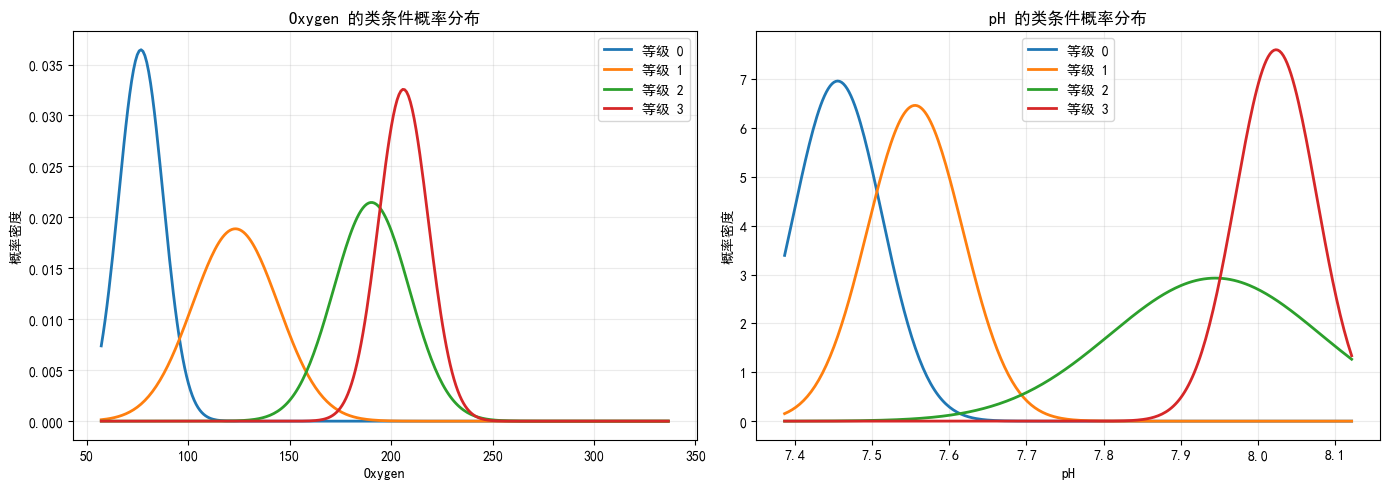

朴素贝叶斯优先展示的分布特征：
- Oxygen
- pH


In [24]:
# 23. 朴素贝叶斯：概率分布图
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

if 'df' in globals() and 'QualityLevel' in df.columns:
    df_nb = df.copy()
else:
    df_nb = pd.read_csv('waterdata_ready_for_ml_weighted_no_unit.csv')

nb_features = ['Depth', 'Temperature', 'Salinity', 'Oxygen', 'pH', 'DO_mgL']
X_nb = df_nb[nb_features].copy()

if df_nb['QualityLevel'].dtype == 'object':
    label_encoder_nb = LabelEncoder()
    y_nb = label_encoder_nb.fit_transform(df_nb['QualityLevel'])
    nb_class_labels = [str(name) for name in label_encoder_nb.classes_]
else:
    y_nb = df_nb['QualityLevel'].to_numpy()
    nb_class_labels = [f'等级 {cls}' for cls in np.unique(y_nb)]

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb, y_nb, test_size=0.2, random_state=42, stratify=y_nb
)

nb_model = GaussianNB()
nb_model.fit(X_train_nb, y_train_nb)

class_means_nb = pd.DataFrame(X_train_nb).groupby(y_train_nb).mean()
class_vars_nb = pd.DataFrame(X_train_nb).groupby(y_train_nb).var().replace(0, 1e-6)
feature_scores_nb = ((class_means_nb.var(axis=0)) / (class_vars_nb.mean(axis=0) + 1e-6)).sort_values(ascending=False)
ranked_features_nb = feature_scores_nb.index.tolist()
selected_features_nb = ranked_features_nb[:2]
if 'DO_mgL' in selected_features_nb and len(ranked_features_nb) >= 3:
    third_feature_nb = ranked_features_nb[2]
    selected_features_nb = [feature for feature in selected_features_nb if feature != 'DO_mgL']
    if third_feature_nb not in selected_features_nb:
        selected_features_nb.append(third_feature_nb)
selected_features_nb = selected_features_nb[:2]

x_grids_nb = {
    feature: np.linspace(X_train_nb[feature].min(), X_train_nb[feature].max(), 300)
    for feature in selected_features_nb
}

fig, axes = plt.subplots(1, len(selected_features_nb), figsize=(7 * len(selected_features_nb), 5))
if len(selected_features_nb) == 1:
    axes = [axes]

for ax, feature_name in zip(axes, selected_features_nb):
    feature_idx = nb_features.index(feature_name)
    x_grid_nb = x_grids_nb[feature_name]
    for class_idx, class_value in enumerate(nb_model.classes_):
        mean_nb = nb_model.theta_[class_idx, feature_idx]
        var_nb = nb_model.var_[class_idx, feature_idx]
        std_nb = np.sqrt(var_nb)
        pdf_nb = (1 / (std_nb * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_grid_nb - mean_nb) / std_nb) ** 2)
        label_idx_nb = int(class_value) if int(class_value) < len(nb_class_labels) else class_idx
        ax.plot(x_grid_nb, pdf_nb, linewidth=2, label=nb_class_labels[label_idx_nb])

    ax.set_title(f'{feature_name} 的类条件概率分布')
    ax.set_xlabel(feature_name)
    ax.set_ylabel('概率密度')
    ax.grid(alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()

print('朴素贝叶斯优先展示的分布特征：')
for feature_name in selected_features_nb:
    print(f'- {feature_name}')

### 图表说明

1. 概率分布图：展示在朴素贝叶斯假设下，不同类别在某一特征上的类条件高斯分布。曲线峰值位置代表该类别在该特征上的典型取值，曲线宽度反映波动范围。
2. 如果不同类别的分布曲线分离较明显，说明该特征对分类更有帮助；如果多条曲线高度重叠，说明该特征单独拿出来时区分能力较弱。
3. 本单元仍然只展示两个特征，但如果前两名里包含 DO_mgL，就会用排序第 3 的特征替换它，以避免与 Oxygen 的强相关性造成展示信息重复。